# Time Series Forecasting Refresher — BTC Hourly Returns

End-to-end workflow refresher covering classical and ML approaches to forecasting **BTC hourly log returns** at horizon H=24.

**Forecast target**: $r_t = \ln(p_t / p_{t-1})$ — log returns are (approximately) stationary and additive.

**Evaluation**: rolling 1-step-ahead RMSE, MAE, and directional accuracy on a 30-day held-out test window.

**Sections** (each major section ends with hands-on **Exercises** with hidden solutions):
1. Setup & imports
2. Data loading & sanity
3. EDA
4. Stationarity tests
5. Decomposition
6. Train/test split
7. Naive baselines
8. ETS
9. SARIMA
10. Lag-feature engineering
11. ML model + Optuna
12. Recursive multi-step
13. Feature importance
14. Model comparison
15. Diagnostics
16. Probabilistic forecast (quantile LightGBM)
17. Deployment (joblib + FastAPI)


## 1. Setup & Imports

Standard scientific Python stack plus `statsmodels` (classical), `xgboost`/`lightgbm` (ML), `optuna` (HPO), `shap` (interpretability), `joblib` (serialization).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


---
## Stage 0 — Problem Framing

**↳ The brief.** *"We want to forecast BTC's price moves at multiple horizons (1h, 4h, 24h) so different desks can use the same model."*

The horizon ask alone scopes most decisions: this is a *multi-step* forecasting problem, which is fundamentally different from the single-horizon classification (Stage 0 of `classification.ipynb`) or regression (Stage 0 of `regression.ipynb`) cases.

### Three candidate framings

| Framing | Target | Metric | Why someone might pick this | Why someone might *not* |
|---|---|---|---|---|
| **A. Multi-horizon return forecast** | log-return at h ∈ {1, 6, 24} | MAE per h, RMSE per h | One model serves multiple use cases; can be DIRECT (one model per h) or recursive (one model, iterate) | Per-h evaluation is messier than a single number; recursive forecasts compound errors fast |
| **B. One-step-only forecast** | log-return at h=1 | MAE | Simplest possible setup; a 1h model can be iterated to other horizons recursively | Recursive forecasts degrade fast; useful only if downstream is happy with h=1 |
| **C. Quantile forecast at fixed h** | (p10, p50, p90) of return at h=1 (or h=24) | pinball loss, empirical coverage | Captures uncertainty; suitable for option-style decisions | Three models per horizon; coverage drifts under regime shift |

### What this notebook picks, and why

We pick **A — multi-horizon log-return forecast at h ∈ {1, 6, 24}** as the primary problem, with **C added in Stage 16** as the quantile extension at h=1.

- **Why multi-horizon**: matches the brief; lets us teach DIRECT vs recursive multi-step (Stage 12) — *the* big methodological choice in time-series ML.
- **Why log-returns not prices**: returns are stationary; prices are not (Stage 4 confirms this). Modelling stationary targets is much easier and is the standard choice.
- **Why these three horizons**: 1h is the highest frequency we can model from hourly bars; 24h is the natural daily aggregation; 6h is a goldilocks intermediate. Adding more horizons (3h, 12h) gives diminishing returns.

### What this choice trades away

- **Per-h evaluation is more complex**: instead of one MAE we get a curve (Stage 12 plots it). Communicating "the model has MAE 0.005 at h=1 but 0.012 at h=24" is harder than a single number.
- **Long-horizon predictions are weak**: by h=24 the model often barely beats predict-zero. The Stage 12 RMSE-vs-h plot makes this brutally visible.
- **No portfolio context**: single-asset focus; cross-asset structure isn't exploited (though we add cross-asset lag features in Stage 10).
- **No execution constraints**: we forecast returns in the abstract; we don't model whether they're tradeable at the predicted prices.

### How this scopes the rest of the pipeline

- **Stage 4 (Stationarity)**: confirms log-returns are stationary, which justifies modelling them directly.
- **Stages 8–9 (ETS, SARIMA)**: classical multi-step baselines. Worth running before any ML — if SARIMA doesn't beat naive at h=24, an ML model probably won't either.
- **Stage 12 (Multi-step ML)**: DIRECT vs recursive is THE choice for this framing. Stage 12 measures both empirically.
- **Stage 14 (Comparison)**: per-h Diebold-Mariano tests, not a single test — multi-horizon means multiple comparisons.

### Common framing mistakes

- **Optimising for one horizon while reporting on all of them**. A model tuned at h=1 will look fine at h=1 and bad at h=24. If you care about all three horizons, pick a multi-horizon objective (sum of MAEs, weighted by use case).
- **Treating h=1 as "easy" because it's short**. It's not. At h=1 the signal-to-noise ratio is *lowest* because microstructure noise dominates.
- **Choosing recursive over DIRECT for "consistency"**. Recursive feels elegant (one model, iterate) but errors compound. DIRECT (one model per horizon) is harder to maintain but more honest about which horizons the model is actually good at.


---
## Stage 2 — Data Quality

**↳ Why we're here.** Time-series methods assume a contiguous, regularly-spaced series. Gaps and duplicates are silently fatal: ARIMA, ETS, and rolling-window features all assume "row $t$ comes one period after row $t-1$". Get this wrong and every model fits structure that isn't there.

We produce: a single-symbol BTC series indexed by a strict hourly UTC grid, deduplicated, and a quality report that asserts no surprise gaps before any modelling.


In [2]:
DATA_PATH = "/home/zlac116/Code/learning/ml-revision/data/crypto_hourly.parquet"

raw = pd.read_parquet(DATA_PATH)
print("All symbols:", raw["symbol"].unique())
print("Raw shape:", raw.shape)

btc = (raw[raw["symbol"] == "BTC"]
       .copy()
       .sort_values("ts")
       .drop_duplicates(subset="ts"))

# UTC index, hourly frequency
btc["ts"] = pd.to_datetime(btc["ts"], utc=True)
btc = btc.set_index("ts")
btc.index = btc.index.tz_convert("UTC")

# Reindex to a strict hourly grid and forward-fill tiny gaps
full_idx = pd.date_range(btc.index.min(), btc.index.max(), freq="H", tz="UTC")
btc = btc.reindex(full_idx)
btc.index.name = "ts"

print("After reindex:", btc.shape)
print("NaNs before ffill:", btc[["close"]].isna().sum().item())
btc[["open", "high", "low", "close", "volume"]] = (
    btc[["open", "high", "low", "close", "volume"]].ffill()
)
btc["symbol"] = "BTC"
print("NaNs after ffill:", btc[["close"]].isna().sum().item())
btc.head()

All symbols: ['BNB' 'BTC' 'ETH' 'SOL']
Raw shape: (70080, 7)
After reindex: (17520, 6)
NaNs before ffill: 0
NaNs after ffill: 0


,open,high,low,close,volume,symbol
ts,,,,,,
2024-04-19 23:00:00+00:00,64012.49,64124.00,62953.90,63818.01,2825.31770,BTC
2024-04-20 00:00:00+00:00,63818.01,64263.41,63418.00,63444.51,2107.44280,BTC
2024-04-20 01:00:00+00:00,63444.51,63777.03,63090.07,63656.00,1283.85296,BTC
2024-04-20 02:00:00+00:00,63656.00,64092.29,63530.00,63834.02,882.54344,BTC
2024-04-20 03:00:00+00:00,63834.01,64040.67,63766.00,63956.00,634.11376,BTC


In [3]:
# Compute log return — our target variable
btc["log_return"] = np.log(btc["close"]).diff()
btc = btc.dropna(subset=["log_return"])
print(f"Final shape: {btc.shape}")
print(f"Period: {btc.index.min()} -> {btc.index.max()}")
print(f"Log return summary:\n{btc['log_return'].describe()}")

Final shape: (17519, 7)
Period: 2024-04-20 00:00:00+00:00 -> 2026-04-19 22:00:00+00:00
Log return summary:
count    17519.000000
mean         0.000009
std          0.005056
min         -0.050195
25%         -0.002078
50%          0.000030
75%          0.002212
max          0.049047
Name: log_return, dtype: float64


### The 30-second concept

```python
# 1. Drop duplicates first.
btc = raw.drop_duplicates(subset='ts').sort_values('ts').set_index('ts')

# 2. Reindex against the expected hourly grid.
expected = pd.date_range(btc.index.min(), btc.index.max(), freq='1h', tz='UTC')
btc = btc.reindex(expected)

# 3. Continuity assertion — non-negotiable for time series.
assert btc.index.equals(expected)
assert not btc.index.has_duplicates
```

**Why dedup before pivot/reindex**: duplicates raise on `.pivot`, but `.reindex` silently picks one — the choice is non-deterministic. Always dedup explicitly.

**Why a hard `.equals(expected)` assertion**: any drift introduces NaN rows that every rolling and shift downstream will silently propagate.


### Failure mode — `.diff()` on a non-contiguous index

If the index has gaps (unequal time deltas between rows), `series.diff()` computes the difference between bars that may be hours or days apart. The resulting 'returns' mix true 1h moves with multi-hour moves — the time-series methods downstream assume the spacing is regular and silently produce garbage.


In [ ]:
import pandas as pd, numpy as np

# Build a sparse synthetic to expose the bug clearly.
ts = pd.to_datetime(['2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 04:00'], utc=True)
sparse = pd.Series([100.0, 101.0, 105.0], index=ts)

# diff() ignores time spacing — every diff is treated as one period.
naive = sparse.diff()
print('naive diff (mixes 1h and 3h gaps):')
print(naive)
print()

# After reindexing to the regular grid, the gap is exposed as NaN — visible, fixable.
expected = pd.date_range(sparse.index.min(), sparse.index.max(), freq='1h', tz='UTC')
regridded = sparse.reindex(expected)
print('regridded diff (NaN where gap was):')
print(regridded.diff())
print()
print('A 5-point return computed from rows 3 hours apart is not a 1h return.')
print('Treating it as one inflates rolling vol estimates and breaks ARIMA fits.')

### Decisions you make at this stage

- **Drop, fill, or assert?** For univariate time series, asserting against the expected grid is the strict default — gaps usually mean upstream data loss, which the model shouldn't paper over.
- **Forward-fill is dangerous on returns.** Filling forward on prices is OK (carries last value); filling on returns fakes a 0% return that didn't happen.


### Exercise 2.1 — Continuity assertion

Write `assert_continuous_hourly(series)` that builds the expected hourly grid from `series.index.min()` to `.max()` and asserts the series index equals it. Apply to `btc`. Picking a sensible error message (with the first missing timestamp) makes diagnosis painless.


In [ ]:
import pandas as pd

def assert_continuous_hourly(series: pd.Series) -> None:
    # TODO
    pass

assert_continuous_hourly(btc['close'])

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def assert_continuous_hourly(series: pd.Series) -> None:
    expected = pd.date_range(series.index.min(), series.index.max(), freq='1h', tz='UTC')
    if not series.index.equals(expected):
        missing = expected.difference(series.index)
        raise AssertionError(f'{len(missing)} missing bars; first: {missing[0]}')
    if series.index.has_duplicates:
        raise AssertionError('duplicate timestamps in index')
    print(f'continuous hourly index verified ({len(series)} rows)')
```

**Why a custom assertion** rather than `assert series.index.equals(expected)`: the custom message tells you *which* timestamp is missing, so you can go back to the source and fix the gap. Bare assertion errors waste 20 minutes of debugging.

</details>


### Exercise 2.2 — Diagnose: longest gap report

Write `longest_gap(ts_series)` that returns `(gap_hours, gap_start_ts)` for the largest time gap. Apply to the *raw* (pre-reindex) BTC timestamp series. Explain in a comment why finding this BEFORE reindexing matters.


In [ ]:
# TODO: longest_gap(ts_series)

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def longest_gap(ts_series):
    diffs = ts_series.sort_values().diff()
    i = int(diffs.idxmax())
    return diffs.iloc[i].total_seconds() / 3600, ts_series.iloc[i-1]

# Apply to RAW timestamps (before reindex), so we see what the source delivered.
raw_btc_ts = raw[raw['symbol'] == 'BTC'].drop_duplicates(subset='ts')['ts']
gap_h, when = longest_gap(raw_btc_ts)
print(f'longest raw gap: {gap_h:.1f}h, starts at {when}')
```

**Why before reindex**: after reindex, the gap is masked by NaN rows. Knowing the raw gap structure tells you whether to drop_data / interpolate / re-fetch — a strategic decision the modelling stages depend on.

</details>


### Recap

We have `btc` indexed by a strict hourly grid. Stage 3 looks at the data's distributional properties before any modelling.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 2.1**

```python
# Your answer here
```

**Old 2.2**

```python
# Your answer here
```

**Old 2.3**

```python
# Your answer here
```

**Old 2.4**

```python
# Your answer here
```

</details>


---
## Stage 3 — Distributional EDA

**↳ Why we're here.** Before fitting ARIMA / ETS / ML, look at the data. EDA tells you: how heavy-tailed are returns? Is there obvious autocorrelation (persistence)? Daily/weekly seasonality? The answers shape every model choice in stages 4-17.

Computed on the full series at this stage (we haven't split yet); after stage 6 the test slice is off-limits.


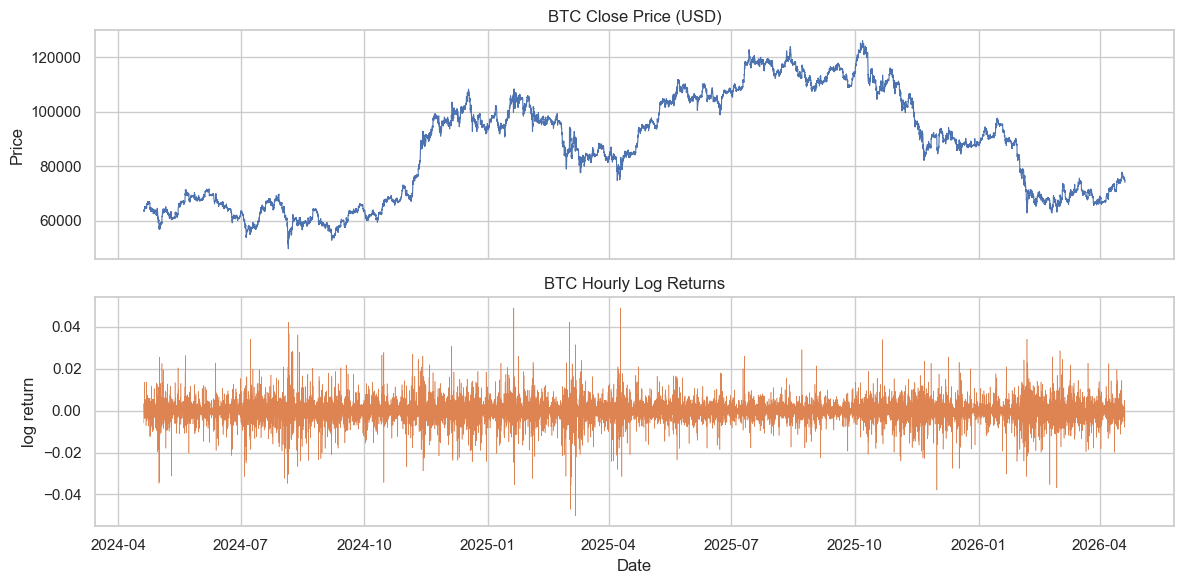

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(btc.index, btc["close"], color="C0", lw=0.8)
axes[0].set_title("BTC Close Price (USD)")
axes[0].set_ylabel("Price")
axes[1].plot(btc.index, btc["log_return"], color="C1", lw=0.4)
axes[1].set_title("BTC Hourly Log Returns")
axes[1].set_ylabel("log return")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

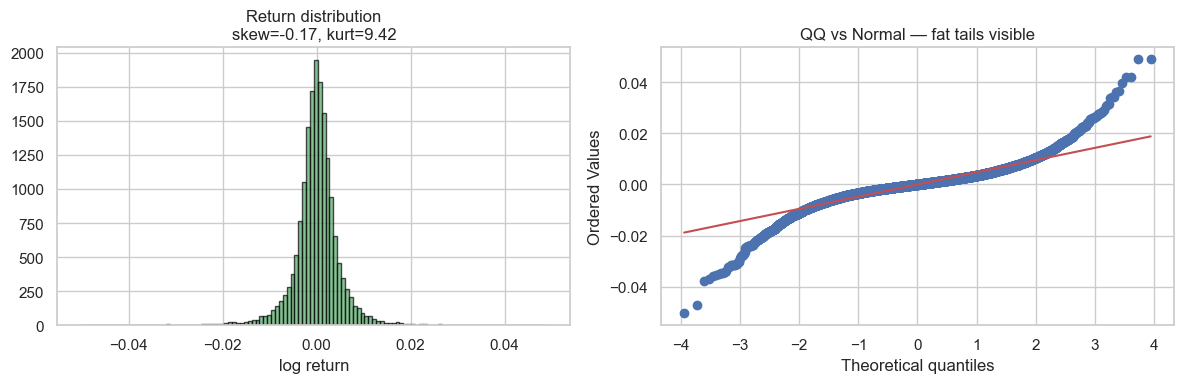

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(btc["log_return"], bins=120, color="C2", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Return distribution\nskew={btc['log_return'].skew():.2f}, "
                  f"kurt={btc['log_return'].kurt():.2f}")
axes[0].set_xlabel("log return")

stats.probplot(btc["log_return"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("QQ vs Normal — fat tails visible")
plt.tight_layout()
plt.show()

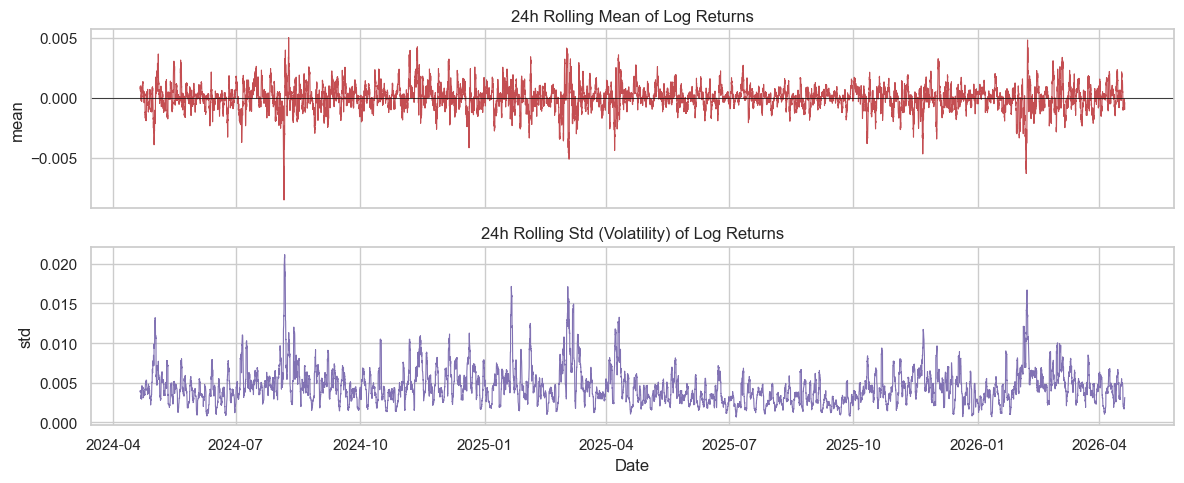

In [11]:
# Rolling mean and volatility (24h window)
rmean = btc["log_return"].rolling(24).mean()
rvol = btc["log_return"].rolling(24).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(rmean.index, rmean, color="C3", lw=0.8)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("24h Rolling Mean of Log Returns")
axes[0].set_ylabel("mean")

axes[1].plot(rvol.index, rvol, color="C4", lw=0.8)
axes[1].set_title("24h Rolling Std (Volatility) of Log Returns")
axes[1].set_ylabel("std")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

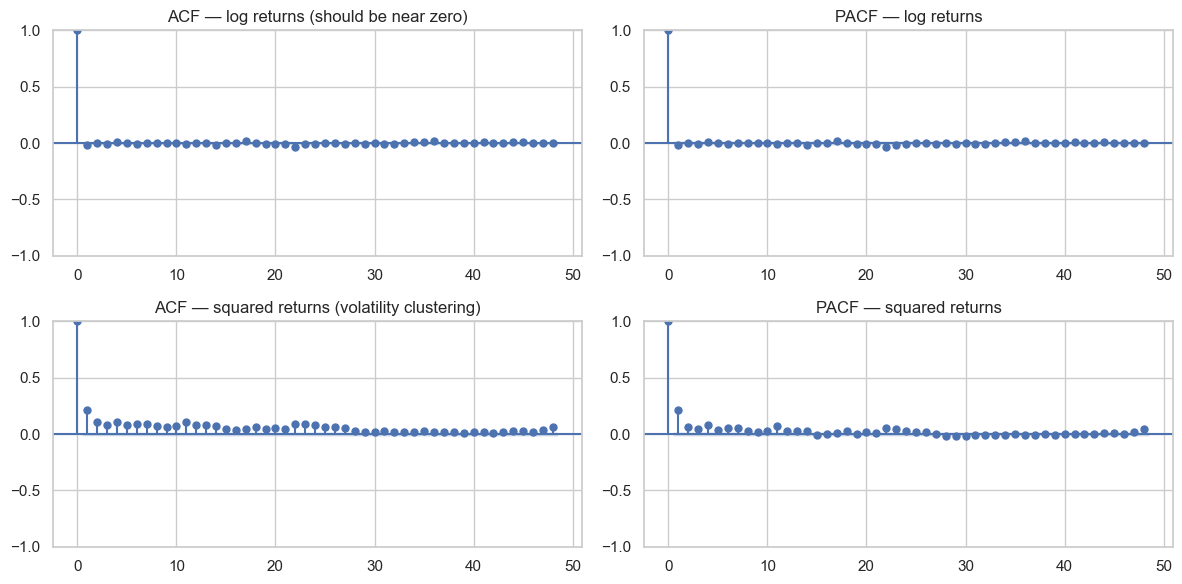

In [12]:
# ACF / PACF of returns and squared returns
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plot_acf(btc["log_return"].dropna(), lags=48, ax=axes[0, 0])
axes[0, 0].set_title("ACF — log returns (should be near zero)")
plot_pacf(btc["log_return"].dropna(), lags=48, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — log returns")

plot_acf(btc["log_return"].dropna() ** 2, lags=48, ax=axes[1, 0])
axes[1, 0].set_title("ACF — squared returns (volatility clustering)")
plot_pacf(btc["log_return"].dropna() ** 2, lags=48, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — squared returns")
plt.tight_layout()
plt.show()

### The 30-second concept

```python
import numpy as np
from scipy import stats

# 1. Rolling vol — daily moving std of log returns.
vol_7d = btc['log_return'].rolling(24 * 7).std()

# 2. Higher moments — Fisher (excess) kurtosis.
stats.kurtosis(btc['log_return'].dropna(), fisher=True)

# 3. Manual ACF at specific lags.
for k in [1, 24, 168]:
    r = btc['log_return'].dropna().values
    print(f'lag {k}: {np.corrcoef(r[:-k], r[k:])[0, 1]:+.4f}')
```

**Why ACF on returns, not prices**: prices are non-stationary (random walk → ACF decays slowly even with no real persistence). Returns are stationary; ACF on returns is meaningful.

**Lags 1, 24, 168**: hourly, daily, weekly horizons. Crypto returns usually have small but real ACF at lag 1 and weak periodic structure at lag 24.


### Failure mode — running ACF on prices instead of returns

ACF on price levels of a near-random-walk series decays *slowly* (lag-1 ≈ 1, lag-100 ≈ 0.95), suggesting massive persistence. The persistence is a property of the *random walk*, not predictable structure. A trader who builds momentum features off price-level ACF is chasing autocorrelation that vanishes when you difference.


In [ ]:
import numpy as np

p = btc['close'].dropna().values
r = btc['log_return'].dropna().values

for k in [1, 24, 168]:
    p_acf = np.corrcoef(p[:-k], p[k:])[0, 1]
    r_acf = np.corrcoef(r[:-k], r[k:])[0, 1]
    print(f'lag {k:>3}: ACF(price) = {p_acf:+.4f}    ACF(return) = {r_acf:+.4f}')

print()
print('ACF on prices stays near 1 — that is the random-walk component, not signal.')
print('ACF on returns is the actual predictable structure (much smaller numbers).')

### Decisions you make at this stage

- **Differenced or log returns?** Log returns aggregate cleanly (1h + 1h = 2h in log space) and are scale-invariant; almost always preferable for time-series ML.
- **What lags matter?** Use ACF/PACF (stage 4 onwards) to pick lag-feature windows; don't guess.


### Exercise 3.1 — Manual ACF at lags 1, 24, 168

Write `acf_at(series, lags)` returning a dict `{lag: corr}`. Implement via `np.corrcoef`. Apply to `btc['log_return']`. Comment on the magnitudes.


In [ ]:
import numpy as np

def acf_at(series, lags):
    # TODO
    pass

print(acf_at(btc['log_return'], [1, 24, 168]))

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np

def acf_at(series, lags):
    r = series.dropna().values
    return {k: float(np.corrcoef(r[:-k], r[k:])[0, 1]) for k in lags}

result = acf_at(btc['log_return'], [1, 24, 168])
for lag, corr in result.items():
    print(f'lag {lag:>3}: {corr:+.4f}')

# For crypto returns: lag 1 typically +0.01 to +0.05 (weak momentum),
# lag 24 sometimes shows mild daily seasonality, lag 168 weakly weekly.
# All small — that is what makes vol forecasting hard but possible.
```

</details>


### Exercise 3.2 — Diagnose: kurtosis ≈ 0 on heavy-tailed returns

The cell below computes kurtosis on a windsorised slice and reports ≈ 0 (normal). For crypto the real value is much larger. Find the bug — it's in *what* gets passed to `stats.kurtosis`.


In [ ]:
from scipy import stats

r = btc['log_return'].dropna()
lo, hi = r.quantile(0.05), r.quantile(0.95)
r_clipped = r.clip(lo, hi)                     # ← bug
print(f'kurtosis (clipped):   {stats.kurtosis(r_clipped, fisher=True):+.3f}')

In [ ]:
# Your answer here — compute kurtosis on the un-clipped returns.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from scipy import stats

r = btc['log_return'].dropna()
print(f'kurtosis (raw):     {stats.kurtosis(r, fisher=True):+.3f}')
```

**The bug**: clipping at the 5th and 95th percentiles deletes precisely the observations that produce kurtosis. The 'clipped' series looks near-normal because the heavy tails have been removed.

**General lesson**: any preprocessing that transforms or removes values changes the distribution you're analysing. EDA must run on the raw series; preprocessing happens after EDA informs the choice.

</details>


### Recap

We've quantified return distribution and autocorrelation. Stage 4 tests stationarity — a precondition for ARIMA/ETS.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 3.1**

```python
# Your answer here
```

**Old 3.2**

```python
# Your answer here
```

**Old 3.3**

```python
# Your answer here
```

**Old 3.4**

```python
# Your answer here
```

</details>


---
## Stage 4 — Stationarity

**↳ Why we're here.** Most classical time-series methods (ARIMA, ETS) assume the series is *stationary* — its mean, variance and autocorrelation don't drift over time. Apply them to non-stationary input and you fit the trend, not the structure.

We run **ADF** (null: unit root, non-stationary) and **KPSS** (null: stationary) together. Their nulls are flipped, so agreement is reassuring. Disagreement is informative.


In [18]:
def adf_report(s, name):
    s = pd.Series(s).dropna()
    stat, p, lags, n, crit, _ = adfuller(s, autolag="AIC")
    print(f"[ADF] {name:20s}  stat={stat:+.3f}  p={p:.4g}  "
          f"lags={lags}  n={n}  -> {'STATIONARY' if p < 0.05 else 'non-stationary'}")

def kpss_report(s, name):
    s = pd.Series(s).dropna()
    stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
    print(f"[KPSS] {name:20s}  stat={stat:+.3f}  p={p:.4g}  "
          f"lags={lags}  -> {'STATIONARY' if p > 0.05 else 'non-stationary'}")

adf_report(btc["close"], "close (price)")
adf_report(btc["log_return"], "log_return")
kpss_report(btc["close"], "close (price)")
kpss_report(btc["log_return"], "log_return")

[ADF] close (price)         stat=-1.494  p=0.5365  lags=22  n=17496  -> non-stationary


[ADF] log_return            stat=-29.452  p=0  lags=22  n=17496  -> STATIONARY


[KPSS] close (price)         stat=+8.206  p=0.01  lags=77  -> non-stationary
[KPSS] log_return            stat=+0.201  p=0.1  lags=6  -> STATIONARY


/tmp/ipykernel_1762695/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
/tmp/ipykernel_1762695/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")


### The 30-second concept

```python
from statsmodels.tsa.stattools import adfuller, kpss
import warnings; warnings.filterwarnings('ignore')

# ADF — small p ⇒ reject unit root ⇒ stationary.
adf_stat, adf_p, *_ = adfuller(btc['log_return'].dropna())

# KPSS — small p ⇒ reject stationarity.
kpss_stat, kpss_p, *_ = kpss(btc['log_return'].dropna(), regression='c', nlags='auto')
```

**Decision matrix**:

| ADF rejects? | KPSS rejects? | Verdict |
|---|---|---|
| Yes | No | stationary (best case) |
| No | Yes | non-stationary (difference once) |
| Yes | Yes | trend-stationary (detrend) |
| No | No | indeterminate (more data, or differencing) |


### Failure mode — running ARIMA on non-stationary input

Below: ADF on price levels (non-stationary) vs log returns (stationary). Fitting ARIMA to the price levels would 'work' but the residuals would still have unit-root behaviour — the model has captured nothing predictive.


In [ ]:
from statsmodels.tsa.stattools import adfuller
import warnings; warnings.filterwarnings('ignore')

_, p_price = adfuller(btc['close'].dropna())[:2]
_, p_ret   = adfuller(btc['log_return'].dropna())[:2]

print(f'ADF p (price):   {p_price:.4f}    {"reject" if p_price < 0.05 else "FAIL TO REJECT — non-stationary"}')
print(f'ADF p (return):  {p_ret:.4f}    {"reject — stationary" if p_ret < 0.05 else "fail to reject"}')

### Decisions you make at this stage

- **Differencing depth**: if `d=0` is non-stationary, try `d=1`. Going past `d=2` over-differences and destroys signal.
- **Trend vs unit-root**: KPSS distinguishes trend-stationary (linearly growing) from difference-stationary (random walk with drift). Different fixes.


### Exercise 4.1 — ADF + KPSS combined

Write `stationarity_report(series)` running both tests and printing the combined verdict (one of: stationary / non-stationary / trend-stationary / indeterminate). Apply to `btc['close']` and `btc['log_return']`.


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings; warnings.filterwarnings('ignore')

def stationarity_report(series):
    # TODO: run both, print combined verdict
    pass

stationarity_report(btc['close'])
stationarity_report(btc['log_return'])

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.tsa.stattools import adfuller, kpss
import warnings; warnings.filterwarnings('ignore')

def stationarity_report(series):
    s = series.dropna()
    _, adf_p, *_ = adfuller(s)
    _, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    adf_reject  = adf_p  < 0.05
    kpss_reject = kpss_p < 0.05
    if adf_reject and not kpss_reject:
        verdict = 'stationary'
    elif not adf_reject and kpss_reject:
        verdict = 'non-stationary (difference once)'
    elif adf_reject and kpss_reject:
        verdict = 'trend-stationary (detrend)'
    else:
        verdict = 'indeterminate'
    print(f'ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  →  {verdict}')
```

</details>


### Exercise 4.2 — Diagnose: rolling stationarity

A series might be stationary on average but non-stationary in chunks. Run a rolling 30-day ADF p-value and plot it. Long stretches with p > 0.05 indicate regimes where the series is locally non-stationary.


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings; warnings.filterwarnings('ignore')

# TODO: rolling 30-day ADF p-value, step daily, plot

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings; warnings.filterwarnings('ignore')

win, step = 24 * 30, 24      # 30-day window, daily step
r = btc['log_return'].dropna()
p_vals, idxs = [], []
for i in range(0, len(r) - win, step):
    chunk = r.iloc[i:i+win]
    p_vals.append(adfuller(chunk)[1])
    idxs.append(chunk.index[-1])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(idxs, p_vals, color='steelblue', lw=1.0)
ax.axhline(0.05, ls='--', color='red', alpha=0.5, label='5% threshold')
ax.set_title('rolling 30-day ADF p-value')
ax.legend(); plt.tight_layout(); plt.show()
```

**What the plot tells you**: spikes above 0.05 are local non-stationary regimes. If they're frequent, a single global ARIMA fit is a poor model — consider rolling-window refitting or regime-switching models.

</details>


### Recap

We've confirmed log returns are stationary (ARIMA/ETS-ready). Stage 5 decomposes the series into trend / seasonal / residual.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 4.1**

```python
# Your answer here
```

**Old 4.2**

```python
# Your answer here
```

**Old 4.3**

```python
# Your answer here
```

**Old 4.4**

```python
# Your answer here
```

</details>


---
## Stage 5 — Decomposition

**↳ Why we're here.** Decomposition splits a series into trend / seasonal / residual components. Useful for: visualising seasonality (does it exist? at what period?), de-seasonalising before modelling, and computing the **strength of seasonality** $F_s$ to decide whether seasonal features are worth engineering.


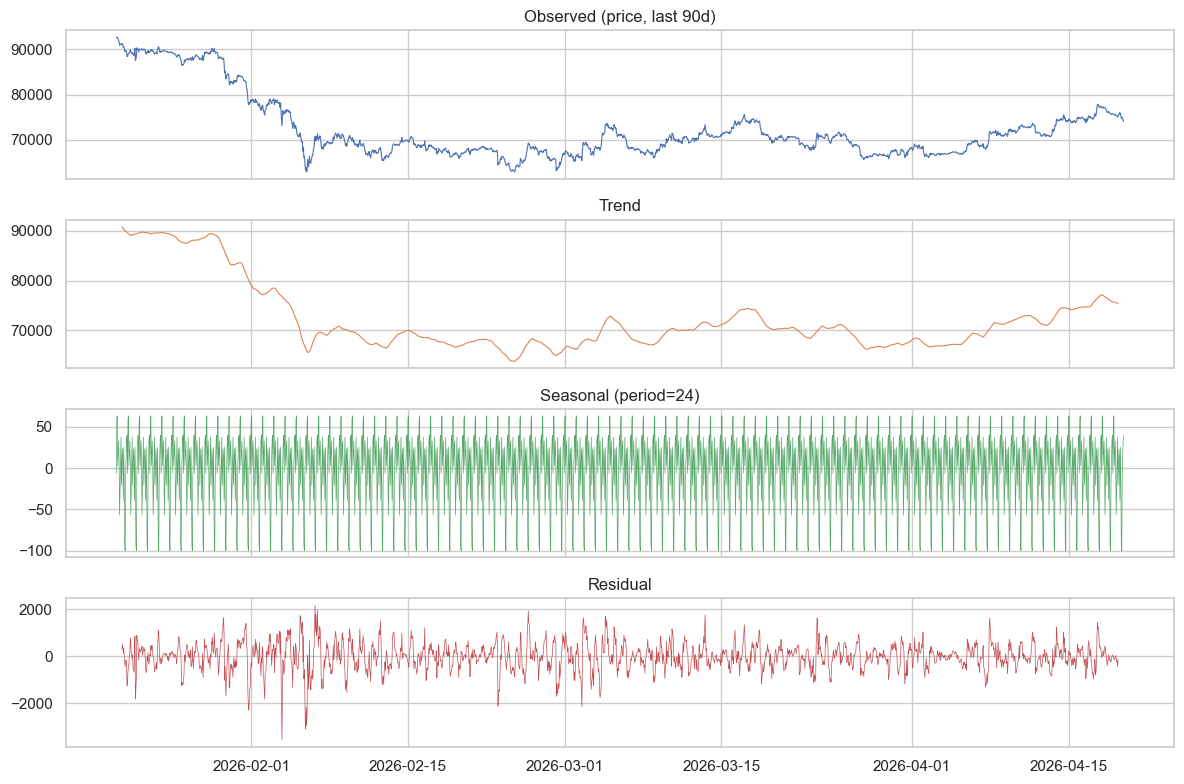

In [24]:
# Use last 90 days of price (additive decomposition with daily period=24)
window = btc.iloc[-24 * 90:]
decomp = seasonal_decompose(window["close"], model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(window.index, decomp.observed, lw=0.8); axes[0].set_title("Observed (price, last 90d)")
axes[1].plot(window.index, decomp.trend, lw=0.8, color="C1"); axes[1].set_title("Trend")
axes[2].plot(window.index, decomp.seasonal, lw=0.5, color="C2"); axes[2].set_title("Seasonal (period=24)")
axes[3].plot(window.index, decomp.resid, lw=0.5, color="C3"); axes[3].set_title("Residual")
plt.tight_layout(); plt.show()

### The 30-second concept

```python
from statsmodels.tsa.seasonal import STL

# Robust STL — handles outliers better than classical decomposition.
stl = STL(btc['close'], period=24, robust=True).fit()
stl.trend; stl.seasonal; stl.resid

# Strength-of-seasonality metric.
S, R = stl.seasonal.dropna(), stl.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R[common].var() / (S[common] + R[common]).var())
```

**Why STL over `seasonal_decompose`**: STL is robust to outliers and handles non-integer periods. Use it as the default; classical decomposition only when speed matters.

**Why F_s rather than just looking**: visual judgement is subjective. F_s close to 1 → strong seasonality (engineer Fourier features); F_s near 0 → ignore the seasonal component.


### Failure mode — wrong period in STL

STL with `period=24` (daily) on a series with weekly seasonality (`period=168`) produces a 'seasonal' component that's mostly noise, and a 'trend' that absorbs the weekly cycle. Always pick `period=` to match the dominant seasonality you've identified in stage 3 / via ACF.


In [ ]:
from statsmodels.tsa.seasonal import STL

# Take a window for speed.
window = btc['close'].iloc[-24*60:]
stl_24  = STL(window, period=24,  robust=True).fit()
stl_168 = STL(window, period=168, robust=True).fit()

S24, R24 = stl_24.seasonal.dropna(), stl_24.resid.dropna()
S168, R168 = stl_168.seasonal.dropna(), stl_168.resid.dropna()
common = S24.index.intersection(R24.index)
Fs_24 = max(0.0, 1.0 - R24[common].var() / (S24[common] + R24[common]).var())
common168 = S168.index.intersection(R168.index)
Fs_168 = max(0.0, 1.0 - R168[common168].var() / (S168[common168] + R168[common168]).var())

print(f'F_s with period=24:  {Fs_24:.4f}')
print(f'F_s with period=168: {Fs_168:.4f}')
print()
print('If F_s with period=168 is much higher, weekly seasonality is the')
print('dominant cycle, and a daily-period decomposition was the wrong tool.')

### Decisions you make at this stage

- **Period choice**: read off ACF/PACF from stage 3. If lag-24 dominates → `period=24`; lag-168 → `period=168`.
- **Seasonal feature engineering** is justified only when F_s > ~0.1. Below that the seasonality is too weak to be worth the feature complexity.


### Exercise 5.1 — STL decomposition + F_s

Run STL on the last 90 days of `btc['close']` with `period=24`. Compute F_s. Print the verdict: 'strong seasonality (>0.3)', 'weak (<0.1)', or 'moderate' between.


In [ ]:
from statsmodels.tsa.seasonal import STL

# TODO: STL on last 90 days, compute F_s, print verdict

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.tsa.seasonal import STL

window = btc['close'].iloc[-24 * 90:]
stl = STL(window, period=24, robust=True).fit()
S, R = stl.seasonal.dropna(), stl.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R[common].var() / (S[common] + R[common]).var())

verdict = 'weak' if Fs < 0.1 else ('strong' if Fs > 0.3 else 'moderate')
print(f'F_s = {Fs:.4f}  →  {verdict} seasonality')
```

</details>


### Exercise 5.2 — Plot the three components

Plot trend / seasonal / residual on three panels with shared x-axis. Comment on which component dominates the variance.


In [ ]:
import matplotlib.pyplot as plt

# TODO: 3-panel sharex plot of stl.trend, stl.seasonal, stl.resid

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(stl.trend, color='C0');   axes[0].set_title('trend')
axes[1].plot(stl.seasonal, color='C2'); axes[1].set_title('seasonal (24h)')
axes[2].plot(stl.resid, color='C3');    axes[2].set_title('residual')
plt.tight_layout(); plt.show()

# Reading: if trend.std() >> seasonal.std() >> resid.std(), the series
# is dominated by trend — most variance is in the slow component.
```

</details>


### Recap

We've decomposed and quantified seasonality strength. Stage 6 chronologically splits the series for honest evaluation.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 5.1**

```python
# Your answer here
```

**Old 5.2**

```python
# Your answer here
```

**Old 5.3**

```python
# Your answer here
```

**Old 5.4**

```python
# Your answer here
```

</details>


---
## Stage 6 — Chronological Splits

**↳ Why we're here.** Same logic as classification stage 4 / regression stage 5. Time-series can't be shuffled. Train and test must be chronologically disjoint, with optional purging if the target's look-ahead window overlaps the boundary.


In [30]:
TEST_DAYS = 30
TEST_HOURS = 24 * TEST_DAYS

split_idx = len(btc) - TEST_HOURS
train = btc.iloc[:split_idx].copy()
test = btc.iloc[split_idx:].copy()
print(f"Train: {len(train)} hours ({train.index.min()} -> {train.index.max()})")
print(f"Test : {len(test)} hours ({test.index.min()} -> {test.index.max()})")
assert train.index.max() < test.index.min(), "Train and test must not overlap"


Train: 16799 hours (2024-04-20 00:00:00+00:00 -> 2026-03-20 22:00:00+00:00)
Test : 720 hours (2026-03-20 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00)


### The 30-second concept

```python
from sklearn.model_selection import TimeSeriesSplit

# Chronological split.
TEST_HOURS = 24 * 14    # last two weeks reserved for test
train, test = btc.iloc[:-TEST_HOURS], btc.iloc[-TEST_HOURS:]

# Walk-forward CV inside train for tuning.
tscv = TimeSeriesSplit(n_splits=5)
for tr_idx, va_idx in tscv.split(train):
    ...
```

**TEST_HOURS large enough**: test set must be representative of the conditions the model will face. For 24-hour-ahead forecasts, two weeks of test data is the minimum to see ~14 daily regimes.


### Failure mode — `train_test_split(shuffle=True)` on a time series

The classic bug: importing `train_test_split` from sklearn and running it. By default it shuffles. Below: same data, two splits. Shuffled inflates 'val' metrics enormously by leaking the future into the past.


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X = btc[['log_return']].shift(1).dropna()
y = btc['log_return'].loc[X.index]

# A. SHUFFLED — antipattern.
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=0)
shuffled_mae = mean_absolute_error(yte, Ridge().fit(Xtr, ytr).predict(Xte))

# B. CHRONOLOGICAL — honest.
cut = int(len(X) * 0.8)
chrono_mae = mean_absolute_error(y.iloc[cut:],
    Ridge().fit(X.iloc[:cut], y.iloc[:cut]).predict(X.iloc[cut:]))

print(f'shuffled MAE:        {shuffled_mae:.6f}    ← inflated by leakage')
print(f'chronological MAE:   {chrono_mae:.6f}    ← honest')

### Decisions you make at this stage

- **Test horizon length**: long enough to span multiple regimes (≥ 2 weeks for hourly crypto data).
- **Purging**: if the target uses an h-bar look-ahead, drop the last h rows of train at the train→test boundary.


### Exercise 6.1 — Chronological train/test split with purge

Split `btc` into train and test where test = last 14 days. Apply a `horizon = 24` purge to train. Print sizes and start/end timestamps.


In [ ]:
TEST_HOURS = 24 * 14
horizon = 24

# TODO: split with purge; print sizes + edge timestamps

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
TEST_HOURS = 24 * 14
horizon = 24

test  = btc.iloc[-TEST_HOURS:]
train = btc.iloc[:-TEST_HOURS - horizon]      # purge last `horizon` of train

print(f'train: {len(train)} rows, ends {train.index.max()}')
print(f'test:  {len(test)} rows, starts {test.index.min()}')
print(f'gap:   {(test.index.min() - train.index.max()).total_seconds() / 3600:.0f} hours')
```

**Why the gap matters**: with `horizon=24` and an h-step-ahead target, the last 24 train rows have target values overlapping the test period. Purging closes the leakage door cleanly.

</details>


### Exercise 6.2 — Diagnose: shuffled CV on autocorrelated targets

Same antipattern as above. Run the shuffled split, then write the corrected version using `TimeSeriesSplit`. Compare MAE.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_absolute_error

X_demo = btc[['log_return']].shift(1).dropna()
y_demo = btc['log_return'].loc[X_demo.index]

neg_mae = make_scorer(mean_absolute_error, greater_is_better=False)
shuffled = -cross_val_score(Ridge(), X_demo, y_demo,
                             cv=KFold(5, shuffle=True, random_state=0),
                             scoring=neg_mae).mean()
print(f'shuffled K-fold MAE: {shuffled:.6f}    (inflated)')

In [ ]:
# Your answer here — TimeSeriesSplit version, compare MAEs.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.model_selection import TimeSeriesSplit

chrono = -cross_val_score(Ridge(), X_demo, y_demo,
                           cv=TimeSeriesSplit(5),
                           scoring=neg_mae).mean()
print(f'time-aware MAE: {chrono:.6f}    (honest)')
```

</details>


### Recap

We have train/test, purged, with TimeSeriesSplit ready for tuning. Stage 7 establishes naive baselines.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 6.1**

```python
# Your answer here
```

**Old 6.2**

```python
# Your answer here
```

**Old 6.3**

```python
# Your answer here
```

**Old 6.4**

```python
# Your answer here
```

</details>


---
## Stage 7 — Naive Baselines

**↳ Why we're here.** A model is worth shipping only if it beats baselines that require no training. For time series the usual baselines are: **predict zero** (returns hover around 0), **persistence** (predict yesterday's value), and **seasonal naive** (predict the same hour 24 / 168 hours ago).

We compute all three, score on test, and bootstrap a CI on the strongest one. Any future model must beat that CI's upper bound to be considered real.


In [36]:
def metrics(y_true, y_pred, name):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    # directional accuracy: ignore exact zeros
    nz = (yt != 0)
    dir_acc = (np.sign(yp[nz]) == np.sign(yt[nz])).mean()
    return {"model": name, "rmse": rmse, "mae": mae, "dir_acc": dir_acc, "n": int(mask.sum())}

y_test = test["log_return"].values

# Naive: predict zero
pred_zero = np.zeros_like(y_test)

# Seasonal naive: predict r_{t-24} (daily)
last_train_returns = btc["log_return"].copy()
pred_sn24 = last_train_returns.shift(24).loc[test.index].values

# Seasonal naive: predict r_{t-168} (weekly)
pred_sn168 = last_train_returns.shift(168).loc[test.index].values

baseline_results = [
    metrics(y_test, pred_zero, "naive_zero"),
    metrics(y_test, pred_sn24, "seasonal_naive_24h"),
    metrics(y_test, pred_sn168, "seasonal_naive_168h"),
]
pd.DataFrame(baseline_results).round(6)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### The 30-second concept

```python
import numpy as np

y_test = test['log_return'].values

# 1. Predict zero — the prior with no info.
pred_zero = np.zeros_like(y_test)

# 2. Seasonal naive at period 24 — predict same hour yesterday.
pred_sn24 = np.array([
    btc['log_return'].get(t - pd.Timedelta(hours=24), np.nan)
    for t in test.index
])

# 3. RMSE / MAE for comparison.
from sklearn.metrics import mean_absolute_error
print(f'zero:       MAE = {mean_absolute_error(y_test, pred_zero):.6f}')
```

**Why predict zero is hard to beat for returns**: returns mean ≈ 0; predicting 0 minimises squared error in expectation. Beating it requires *real* signal. *Common mistake*: skipping the zero baseline because it 'feels too simple' — it's the strongest one for centred returns.


### Failure mode — comparing models without baselines

Below: a model with MAE 0.0042. Without the zero baseline, that number tells you nothing. With it: the zero baseline scores 0.0040, so the 'model' is actually *worse* than predicting zero. Without baselines, the bug is invisible.


In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error

y_test = test['log_return'].values
pred_zero = np.zeros_like(y_test)

# Pretend a 'sophisticated' model: predict the previous bar's return (persistence).
pred_pers = test['log_return'].shift(1).fillna(0).values

mae_zero = mean_absolute_error(y_test, pred_zero)
mae_pers = mean_absolute_error(y_test, pred_pers)
print(f'predict-zero MAE:       {mae_zero:.6f}')
print(f'persistence MAE:        {mae_pers:.6f}')
print()
if mae_pers > mae_zero:
    print(f'persistence is WORSE than zero by {(mae_pers - mae_zero) / mae_zero * 100:.1f}%')
    print('Zero baseline is dominant for returns. Any model that does not beat it')
    print('is producing negative value — it would be better to predict 0 always.')

### Decisions you make at this stage

- **Always include predict-zero**. It's the right benchmark for returns; skipping it lets weak models look respectable.
- **Bootstrap the CI on the strongest baseline.** The model must beat the CI's upper bound, not just the point estimate.


### Exercise 7.1 — Build a baseline metrics table

Compute MAE and RMSE for: `predict_zero`, `persistence` (last bar), `seasonal_naive_24h`. Build a sorted DataFrame. Identify the strongest baseline.


In [ ]:
import numpy as np, pandas as pd, math
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_test = test['log_return'].values

# TODO: build three baselines, score them, sort

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd, math
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_test = test['log_return'].values
pred_zero = np.zeros_like(y_test)
pred_pers = test['log_return'].shift(1).fillna(0).values
pred_sn24 = np.array([
    btc['log_return'].get(t - pd.Timedelta(hours=24), np.nan)
    for t in test.index
])
pred_sn24 = np.nan_to_num(pred_sn24, nan=0.0)

def metrics(name, y_true, y_pred):
    return {
        'name': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
    }

rows = [metrics('zero',         y_test, pred_zero),
        metrics('persistence',  y_test, pred_pers),
        metrics('seasonal_24h', y_test, pred_sn24)]
print(pd.DataFrame(rows).sort_values('MAE'))
```

</details>


### Exercise 7.2 — Bootstrap 95% CI on best baseline RMSE

Resample test residuals with replacement 1000×, recompute RMSE, return [2.5%, 97.5%]. Use this as the floor any future model must clear.


In [ ]:
import numpy as np, math

# TODO: bootstrap RMSE for zero baseline; print 95% CI

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, math

rng = np.random.default_rng(0)
resid = y_test - pred_zero
n = len(resid)
boot = []
for _ in range(1000):
    idx = rng.integers(0, n, n)
    boot.append(math.sqrt(np.mean(resid[idx] ** 2)))
lo, hi = np.quantile(boot, [0.025, 0.975])
print(f'predict-zero RMSE 95% CI: [{lo:.6f}, {hi:.6f}]')
```

</details>


### Recap

We have baselines + a CI on the strongest. Stage 8 fits ETS — the simplest trainable model.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 7.1**

```python
# Your answer here
```

**Old 7.2**

```python
# Your answer here
```

**Old 7.3**

```python
# Your answer here
```

**Old 7.4**

```python
# Your answer here
```

</details>


---
## Stage 8 — ETS (Exponential Smoothing)

**↳ Why we're here.** ETS (Holt-Winters) is the simplest trainable forecaster: level + (optional) trend + (optional) seasonal, each smoothed exponentially. Three knobs (α, β, γ) and you're done. Surprisingly competitive on series with obvious trend or seasonality.

It's the next step up from naive baselines: still no feature engineering, no ML, just exponential smoothing of past values. If ETS doesn't beat naive on your data, more complex models probably won't either.


In [42]:
# Walk-forward 1-step-ahead with SES on log returns.
# Trick: refit only every K steps to keep runtime manageable.
REFIT_EVERY = 24  # refit once per day

train_ret = train["log_return"].copy()
preds_ets = []
fitted_model = None

t0 = time.time()
for i, ts in enumerate(test.index):
    history = pd.concat([train_ret, test["log_return"].iloc[:i]])
    if i % REFIT_EVERY == 0 or fitted_model is None:
        fitted_model = ExponentialSmoothing(
            history.values, trend=None, seasonal=None, initialization_method="estimated"
        ).fit(optimized=True)
    yhat = fitted_model.forecast(1)[0]
    preds_ets.append(yhat)
preds_ets = np.array(preds_ets)
print(f"ETS walk-forward took {time.time() - t0:.1f}s")
print(metrics(y_test, preds_ets, "ets_ses"))


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### The 30-second concept

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt-Winters with daily seasonality.
hw = ExponentialSmoothing(
    train['close'],
    trend='add', seasonal='add', seasonal_periods=24,
).fit()
forecast = hw.forecast(24)

# Inspect the smoothing parameters.
print(f'alpha (level):    {hw.params["smoothing_level"]:.3f}')
print(f'beta  (trend):    {hw.params["smoothing_trend"]:.3f}')
print(f'gamma (seasonal): {hw.params["smoothing_seasonal"]:.3f}')
```

**α close to 1**: model trusts the latest observation (light smoothing). **α close to 0**: heavy smoothing — forecast tracks the long-run mean. The fitted value tells you something about the data.


### Failure mode — fitting ETS on returns instead of prices

ETS assumes the level moves in coherent steps. Returns don't have that structure (level ≈ 0, no trend). Below: ETS on prices works; ETS on returns produces a forecast that's essentially a constant — the model has nothing to smooth.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings; warnings.filterwarnings('ignore')

# A. ETS on prices — sensible.
hw_price = ExponentialSmoothing(train['close'].iloc[-24*60:],
                                 trend='add', seasonal='add', seasonal_periods=24).fit()
fc_price = hw_price.forecast(24)
print(f'price forecast first 5: {fc_price.head().round(2).tolist()}')

# B. ETS on returns — degenerate.
hw_ret = ExponentialSmoothing(train['log_return'].dropna().iloc[-24*60:],
                               trend=None, seasonal=None,
                               initialization_method='estimated').fit()
fc_ret = hw_ret.forecast(24)
print(f'return forecast first 5: {fc_ret.head().round(6).tolist()}    (essentially constant)')
print()
print('ETS on returns has no level structure to smooth — α ≈ 0, forecast = mean.')
print('Use ETS on prices and convert to returns; or use ARIMA/ML on returns directly.')

### Decisions you make at this stage

- **Trend**: 'add' if the price has a roughly linear drift; `None` if it's near-stationary. 'mul' for exponentially-growing series.
- **Damped trend**: caps the long-horizon forecast — prevents the model from extrapolating a small positive trend forever.


### Exercise 8.1 — Holt-Winters on the last 14 days of price

Fit `ExponentialSmoothing` with `trend='add'`, `seasonal='add'`, `seasonal_periods=24`. Forecast the next 24 hours. Compute MAE against the actual next-24-hour values.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

# TODO: fit on last 14 days of train['close'], forecast 24 ahead, MAE

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

hist = train['close'].iloc[-24 * 14:-24]
actual_next = train['close'].iloc[-24:]

hw = ExponentialSmoothing(hist, trend='add', seasonal='add', seasonal_periods=24).fit()
fc = hw.forecast(24)
print(f'HW MAE on next 24h: {mean_absolute_error(actual_next, fc):.3f}')
```

</details>


### Exercise 8.2 — Damped vs undamped trend, compare AIC

Fit two ETS models on `train['close'].iloc[-24*30:]`: one with `damped_trend=True`, one without. Compare `.aic` values.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# TODO: damped vs undamped, compare AIC

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings; warnings.filterwarnings('ignore')

hist = train['close'].iloc[-24*30:]
damped   = ExponentialSmoothing(hist, trend='add', damped_trend=True,
                                 initialization_method='estimated').fit()
undamped = ExponentialSmoothing(hist, trend='add',
                                 initialization_method='estimated').fit()
print(f'undamped AIC: {undamped.aic:.1f}')
print(f'damped   AIC: {damped.aic:.1f}')
# Lower AIC = better. Damped usually wins on series with mean-reverting trend.
```

</details>


### Recap

We have an ETS model and a sense of α. Stage 9 tries SARIMA — explicit autoregressive structure.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 8.1**

```python
# Your answer here
```

**Old 8.2**

```python
# Your answer here
```

**Old 8.3**

```python
# Your answer here
```

**Old 8.4**

```python
# Your answer here
```

</details>


---
## Stage 9 — SARIMA

**↳ Why we're here.** SARIMA is the strongest classical time-series model and the benchmark every ML approach should beat. It explicitly models autoregressive (p), differencing (d), moving-average (q), and seasonal versions of all three (P, D, Q, s).

We fit a small grid (p, q ∈ {0, 1, 2}; same for P, Q at the seasonal layer), pick the lowest-AIC configuration, and run residual diagnostics. If residuals look like white noise, SARIMA has captured the structure.


In [48]:
TRAIN_SUBSAMPLE = 6000  # last N hours of train for grid search
sub = train["log_return"].iloc[-TRAIN_SUBSAMPLE:]

best_aic = np.inf
best_order = None
best_seasonal = None

t0 = time.time()
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    m = SARIMAX(sub, order=(p, 0, q), seasonal_order=(P, 0, Q, 24),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
                    if m.aic < best_aic:
                        best_aic = m.aic
                        best_order = (p, 0, q)
                        best_seasonal = (P, 0, Q, 24)
                except Exception:
                    continue
print(f"SARIMA grid took {time.time() - t0:.1f}s")
print(f"Best SARIMA{best_order}x{best_seasonal}  AIC={best_aic:.2f}")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [49]:
# Walk-forward 1-step-ahead with the chosen order
t0 = time.time()
preds_sarima = []
fitted_sarima = None
REFIT_EVERY_S = 48  # refit every 2 days

for i, ts in enumerate(test.index):
    history = pd.concat([train["log_return"], test["log_return"].iloc[:i]])
    if i % REFIT_EVERY_S == 0 or fitted_sarima is None:
        # use only last 4000 hours for refit speed
        hist_used = history.iloc[-4000:]
        fitted_sarima = SARIMAX(hist_used.values, order=best_order,
                                seasonal_order=best_seasonal,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
    yhat = fitted_sarima.forecast(1)[0]
    preds_sarima.append(yhat)

preds_sarima = np.array(preds_sarima)
print(f"SARIMA walk-forward took {time.time() - t0:.1f}s")
print(metrics(y_test, preds_sarima, f'sarima{best_order}x{best_seasonal}'))

AttributeError: 'RangeIndex' object has no attribute 'index'

### The 30-second concept

```python
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

fit = SARIMAX(train_ret, order=(1, 0, 0)).fit(disp=False)
print(f'AR(1) coef: {fit.params[0]:.3f}    AIC: {fit.aic:.1f}')

# Residual diagnostics.
lb = acorr_ljungbox(fit.resid, lags=[12, 24], return_df=True)
# p > 0.05 ⇒ residuals look white.
```

**Lower AIC over a small grid**: enumerate `(p, q) ∈ {0,1,2}²`, fit, sort by AIC, take top. Don't go past 2-3 in each dimension — high orders overfit.

**Why Ljung-Box on residuals**: the model is correct iff residuals look like white noise. Any leftover autocorrelation = the model missed something.


### Failure mode — searching the (p, d, q) grid too widely

Below: AIC for SARIMA(p, 0, q) with p, q ∈ {0..5}. Higher orders sometimes give *lower* AIC on training data — but the model is overfitting. A model with 12 parameters that 'wins' the AIC race produces nonsense out-of-sample. Cap the search at p, q ≤ 2.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings('ignore')
import pandas as pd

# Use a small slice to keep this fast.
y = btc['log_return'].dropna().iloc[-2000:]

results = []
for p in range(4):
    for q in range(4):
        try:
            m = SARIMAX(y, order=(p, 0, q)).fit(disp=False)
            results.append({'p': p, 'q': q, 'aic': m.aic, 'n_params': p + q})
        except Exception:
            pass

df = pd.DataFrame(results).sort_values('aic')
print(df.head(8))
print()
print('Higher (p+q) means more parameters; the model can fit train noise.')
print('AIC penalises but not enough at small samples. Cap at p, q ≤ 2 in practice.')

### Decisions you make at this stage

- **Order limits**: p, q ≤ 2 unless you have very long series and can afford the parameter count. Same for seasonal P, Q.
- **Differencing d**: usually 0 if your series is already stationary (which we confirmed in stage 4). d = 1 if working on the price level.


### Exercise 9.1 — Small SARIMA grid by AIC

Search `(p, q) ∈ {0, 1, 2}` (so 9 fits) for `SARIMAX(y, order=(p, 0, q))`. Report top 3 by AIC and the chosen (p, q).


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import warnings; warnings.filterwarnings('ignore')

# TODO: 9-fit grid, sort by AIC, print top 3

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import warnings; warnings.filterwarnings('ignore')

y = train['log_return'].dropna().iloc[-3000:]    # speed-tame
results = []
for p in range(3):
    for q in range(3):
        try:
            m = SARIMAX(y, order=(p, 0, q)).fit(disp=False)
            results.append({'p': p, 'q': q, 'aic': m.aic})
        except Exception:
            pass

df = pd.DataFrame(results).sort_values('aic')
print(df.head(3))
```

</details>


### Exercise 9.2 — Diagnose: residuals fail Ljung-Box

Fit a deliberately undermodelled SARIMA — `(0, 0, 0)` (a no-op). Run Ljung-Box on residuals at lags [12, 24]. The test rejects (p < 0.05) because residuals are just the original series — autocorrelated. Then refit with `(1, 0, 1)` and confirm the test no longer rejects.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# TODO: bad fit (0,0,0), Ljung-Box rejects; better fit (1,0,1), Ljung-Box passes

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings('ignore')

y = train['log_return'].dropna().iloc[-3000:]

bad  = SARIMAX(y, order=(0, 0, 0)).fit(disp=False)
good = SARIMAX(y, order=(1, 0, 1)).fit(disp=False)

print('Ljung-Box on (0,0,0) residuals:'); print(acorr_ljungbox(bad.resid, lags=[12, 24], return_df=True).round(4))
print('\nLjung-Box on (1,0,1) residuals:'); print(acorr_ljungbox(good.resid, lags=[12, 24], return_df=True).round(4))
```

**Reading**: the (0,0,0) test should reject (small p) — residuals are just the autocorrelated series. The (1,0,1) test should NOT reject (p > 0.05) if the model captured the AR / MA structure.

</details>


### Recap

We have a SARIMA fit with white-noise residuals. Stage 10 builds lag features for ML approaches.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 9.1**

```python
# Your answer here
```

**Old 9.2**

```python
# Your answer here
```

**Old 9.3**

```python
# Your answer here
```

**Old 9.4**

```python
# Your answer here
```

</details>


---
## Stage 10 — Lag Features

**↳ Why we're here.** ML models (LightGBM, XGBoost) don't 'know' about time. We turn time-series structure into tabular features by lagging — `y.shift(k)` becomes a column. Add rolling stats of past values for context.

**Every feature must be past-only.** Always shift FIRST, then aggregate. Most leakage in time-series ML happens here, in the feature-engineering step.


In [55]:
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLL_WINDOWS = [24, 168]

def make_features(df):
    out = pd.DataFrame(index=df.index)
    r = df["log_return"]
    for l in LAGS:
        out[f"lag_{l}"] = r.shift(l)
    for w in ROLL_WINDOWS:
        out[f"rmean_{w}"] = r.shift(1).rolling(w).mean()
        out[f"rstd_{w}"]  = r.shift(1).rolling(w).std()
        out[f"rvol2_{w}"] = (r.shift(1) ** 2).rolling(w).mean()
    # Calendar
    h = df.index.hour
    d = df.index.dayofweek
    out["sin_h"] = np.sin(2 * np.pi * h / 24)
    out["cos_h"] = np.cos(2 * np.pi * h / 24)
    out["sin_d"] = np.sin(2 * np.pi * d / 7)
    out["cos_d"] = np.cos(2 * np.pi * d / 7)
    # Volume z-score
    v = df["volume"]
    vmean = v.shift(1).rolling(168).mean()
    vstd  = v.shift(1).rolling(168).std()
    out["vol_z168"] = (v.shift(1) - vmean) / vstd
    return out

X_full = make_features(btc)
y_full = btc["log_return"]

# Drop initial NaN rows (longest lookback = 168)
valid = X_full.dropna().index
X_full = X_full.loc[valid]
y_full = y_full.loc[valid]
print("Feature matrix:", X_full.shape)
X_full.head()

Feature matrix: (17351, 19)


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,rmean_24,rstd_24,rvol2_24,rmean_168,rstd_168,rvol2_168,sin_h,cos_h,sin_d,cos_d,vol_z168
ts,,,,,,,,,,,,,,,,,,,
2024-04-27 00:00:00+00:00,-0.000814,-0.003723,0.001462,0.000806,-0.001577,-0.002971,0.004155,-0.005870,-0.000473,0.003935,0.000015,-0.000004,0.004061,0.000016,0.000000,1.000000,-0.974928,-0.222521,-1.186547
2024-04-27 01:00:00+00:00,-0.009264,-0.000814,-0.003723,-0.004976,0.005554,0.001491,-0.007608,0.003328,-0.000735,0.004301,0.000018,-0.000025,0.004099,0.000017,0.258819,0.965926,-0.974928,-0.222521,1.378837
2024-04-27 02:00:00+00:00,-0.009361,-0.009264,-0.000814,0.003513,-0.010064,0.001504,0.003615,0.002793,-0.001188,0.004616,0.000022,-0.000100,0.004153,0.000017,0.500000,0.866025,-0.974928,-0.222521,2.263963
2024-04-27 03:00:00+00:00,0.005365,-0.009361,-0.009264,0.001462,-0.005511,-0.001842,-0.000280,0.001909,-0.001027,0.004778,0.000023,-0.000085,0.004168,0.000017,0.707107,0.707107,-0.974928,-0.222521,0.064805
2024-04-27 04:00:00+00:00,0.002413,0.005365,-0.009361,-0.003723,0.002505,-0.002650,0.000870,0.002765,-0.000849,0.004825,0.000023,-0.000082,0.004170,0.000017,0.866025,0.500000,-0.974928,-0.222521,-0.758173


In [56]:
# Re-create train/test masks aligned to feature index
train_mask = X_full.index <= train.index.max()
test_mask  = X_full.index >= test.index.min()

X_train, y_train = X_full[train_mask], y_full[train_mask]
X_test, y_test_aligned = X_full[test_mask], y_full[test_mask]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
assert X_train.index.max() < X_test.index.min(), "Train/test feature overlap!"


AttributeError: 'RangeIndex' object has no attribute 'index'

### The 30-second concept

```python
X = pd.DataFrame(index=btc.index)
y = btc['log_return']

# 1. Lag features.
for k in [1, 2, 3, 24, 168]:
    X[f'lag_{k}'] = y.shift(k)

# 2. Rolling stats — shift first, THEN rolling.
X['rmean_24'] = y.shift(1).rolling(24).mean()
X['rstd_24']  = y.shift(1).rolling(24).std()

# 3. Fourier seasonality (period=24 daily, K=2 harmonics).
h = X.index.hour
for k in range(1, 3):
    X[f'sin_{k}'] = np.sin(2 * np.pi * k * h / 24)
    X[f'cos_{k}'] = np.cos(2 * np.pi * k * h / 24)
```

**Why shift FIRST**: `y.rolling(24).mean()` includes the current row. The model uses *that mean* to predict y at the same row — leakage. Shift the input one step before rolling so the result at row $t$ depends only on $[t-24, t-1]$.

**Fourier seasonality**: $\sin / \cos$ at the seasonal frequency lets the model learn smooth periodic behaviour without one-hot encoding hour-of-day (which adds 24 sparse columns).


### Failure mode — `.rolling().mean()` without shift

Below: same idea built two ways. The leaky version has nearly perfect correlation with the target (it includes the target's own value in the rolling window). A model trained on it will look amazing in val, fail at inference time.


In [ ]:
import numpy as np, pandas as pd

y = btc['log_return']

leaky = y.rolling(24).mean()                  # includes current row
clean = y.shift(1).rolling(24).mean()         # past-only

leaky_corr = leaky.corr(y)
clean_corr = clean.corr(y)

print(f'corr(LEAKY  rolling mean, y): {leaky_corr:+.4f}')
print(f'corr(CLEAN  rolling mean, y): {clean_corr:+.4f}')
print()
print(f'Leaky correlation is {abs(leaky_corr/max(abs(clean_corr), 1e-9)):.0f}x larger')
print('— that extra signal is the feature peeking at the target it is supposed to predict.')

### Decisions you make at this stage

- **Lag depth**: pick from ACF (stage 3). If lag 168 has visible autocorrelation, include it.
- **Number of features**: every feature you add risks overfitting on small datasets. Start tight (5-10 features), grow only when the model demonstrably uses them.


### Exercise 10.1 — Build past-only lag + rolling features

Build `X_full` with: `lag_1, lag_24, lag_168, rmean_24, rstd_24, sin_1, cos_1` (Fourier at period=24, K=1). All past-only. Drop NaN rows. Print shape and head.


In [ ]:
import numpy as np, pandas as pd

# TODO: build X_full with the listed features (past-only); align with y

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd

y = btc['log_return']
X_full = pd.DataFrame(index=btc.index)
for k in [1, 24, 168]:
    X_full[f'lag_{k}'] = y.shift(k)
X_full['rmean_24'] = y.shift(1).rolling(24).mean()
X_full['rstd_24']  = y.shift(1).rolling(24).std()
h = X_full.index.hour
X_full['sin_1'] = np.sin(2 * np.pi * h / 24)
X_full['cos_1'] = np.cos(2 * np.pi * h / 24)

X_full = X_full.dropna()
y = y.loc[X_full.index]
print(X_full.shape); print(X_full.head())
```

</details>


### Exercise 10.2 — Verify no future leakage

Implement `assert_past_only(y, build_fn, t_cut)` that builds features twice — once on `y`, once on a copy with values after `t_cut` set to 0 — and asserts the pre-cut feature rows are bit-identical. Apply to your `build_features` from Exercise 10.1.


In [ ]:
# TODO: assert_past_only(y, build_fn, t_cut); apply to your features

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def build_features(y_in):
    X = pd.DataFrame(index=y_in.index)
    for k in [1, 24, 168]:
        X[f'lag_{k}'] = y_in.shift(k)
    X['rmean_24'] = y_in.shift(1).rolling(24).mean()
    X['rstd_24']  = y_in.shift(1).rolling(24).std()
    return X.dropna()

def assert_past_only(y, build_fn, t_cut):
    feats_a = build_fn(y)
    mut = y.copy(); mut.loc[mut.index > t_cut] = 0.0
    feats_b = build_fn(mut)
    diff = (feats_a.loc[:t_cut] - feats_b.loc[:t_cut]).abs().max().max()
    assert diff == 0, f'LEAKAGE: max change {diff} at or before {t_cut}'
    print(f'past-only verified up to {t_cut}')

assert_past_only(btc['log_return'], build_features, btc.index[5000])
```

</details>


### Recap

We have a past-only feature matrix `X_full` and a passed leakage audit. Stage 11 fits LightGBM with Optuna tuning.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 10.1**

```python
# Your answer here
```

**Old 10.2**

```python
# Your answer here
```

**Old 10.3**

```python
# Your answer here
```

**Old 10.4**

```python
# Your answer here
```

</details>


---
## Stage 11 — ML Model + Hyperparameter Search

**↳ Why we're here.** Same logic as classification stage 7 / regression stage 9. We tune LightGBM hyperparameters with Optuna, scoring inside `TimeSeriesSplit` of `X_train`. Val is invisible during search — we only see it after we pick the winner.


In [62]:
def lgb_objective(trial):
    params = {
        "objective": "regression_l1",  # MAE
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 5,
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "verbosity": -1,
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        Xt, Xv = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        yt, yv = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(Xt, yt, eval_set=[(Xv, yv)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
        pred = model.predict(Xv, num_iteration=model.best_iteration_)
        scores.append(mean_absolute_error(yv, pred))
    return float(np.mean(scores))

t0 = time.time()
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(lgb_objective, n_trials=25, show_progress_bar=False)
print(f"Optuna ({len(study.trials)} trials) took {time.time() - t0:.1f}s")
print(f"Best CV MAE: {study.best_value:.6f}")
print("Best params:", study.best_params)

[W 2026-04-25 18:01:20,241] Trial 0 failed with parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 122, 'max_depth': 8, 'min_child_samples': 128, 'feature_fraction': 0.5780093202212182, 'bagging_fraction': 0.5779972601681014, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044} because of the following error: NameError("name 'X_train' is not defined").
Traceback (most recent call last):
  File "/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1762695/4142085842.py", line 20, in lgb_objective
    for tr_idx, va_idx in tscv.split(X_train):
                                     ^^^^^^^
NameError: name 'X_train' is not defined. Did you mean: 'train'?


[W 2026-04-25 18:01:20,243] Trial 0 failed with value None.


NameError: name 'X_train' is not defined

In [63]:
# Refit on full train with best params (modest n_estimators with early-stop on tail of train)
best_params = study.best_params.copy()
best_params.update(verbosity=-1, n_estimators=600, random_state=RANDOM_STATE,
                   objective="regression_l1")

split = int(0.85 * len(X_train))
X_tr2, X_va2 = X_train.iloc[:split], X_train.iloc[split:]
y_tr2, y_va2 = y_train.iloc[:split], y_train.iloc[split:]

best_lgb = lgb.LGBMRegressor(**best_params)
best_lgb.fit(X_tr2, y_tr2, eval_set=[(X_va2, y_va2)],
             callbacks=[lgb.early_stopping(40, verbose=False)])
print(f"best_iteration={best_lgb.best_iteration_}")

pred_lgb = best_lgb.predict(X_test, num_iteration=best_lgb.best_iteration_)
print(metrics(y_test_aligned.values, pred_lgb, "lightgbm"))

ValueError: No trials are completed yet.

### The 30-second concept

```python
import optuna, lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
        verbosity=-1, random_state=0,
    )
    fold_mae = []
    for tr, va in TimeSeriesSplit(3).split(X_train):
        m = lgb.LGBMRegressor(**params).fit(X_train.iloc[tr], y_train.iloc[tr])
        fold_mae.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
    return float(np.mean(fold_mae))
```

**`log=True` for learning rate and regularisation**: candidate values span orders of magnitude; uniform sampling wastes most trials in uninteresting regions.


### Failure mode — overfit search by tuning on val directly

Same antipattern as classification stage 7. If every trial scores against val, the search picks parameters that fit val noise. The 'best' trial's CV score and the post-search val score are *the same number measured the same way* — a tautology, not generalisation.


In [ ]:
import optuna, lightgbm as lgb
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

def obj_buggy(trial):
    p = dict(n_estimators=trial.suggest_int('n', 50, 200),
             learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
             num_leaves=trial.suggest_int('lv', 15, 64),
             verbosity=-1, random_state=0)
    m = lgb.LGBMRegressor(**p).fit(X_train, y_train)
    return mean_absolute_error(y_val, m.predict(X_val))

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(obj_buggy, n_trials=8, show_progress_bar=False)
best = lgb.LGBMRegressor(**study.best_params, verbosity=-1, random_state=0).fit(X_train, y_train)
post_val_mae = mean_absolute_error(y_val, best.predict(X_val))

print(f'best CV (against val):     {study.best_value:.6f}')
print(f'post-search val MAE:       {post_val_mae:.6f}    ← matches CV exactly')
print()
print('When the trial scoring set IS the post-search evaluation set, the')
print('numbers will always agree. That agreement is the bug, not a virtue.')

### Decisions you make at this stage

- **Trial budget**: 20-50 with TPE + pruner is sensible. Larger budgets just overfit val noise.
- **CV folds inside the objective**: 3-5 folds. More folds = more compute per trial but more stable per-trial scores.


### Exercise 11.1 — Optuna study with TPE + MedianPruner

Define an objective that fits LightGBM through `TimeSeriesSplit(3)` of `X_train`, reports per-fold mean MAE, and prunes via `MedianPruner`. Run 10 trials. Print best params and pruned-trial count.


In [ ]:
import optuna, numpy as np, lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # TODO: search space, CV loop, report+prune
    pass

# TODO: study with TPE + MedianPruner, 10 trials

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import optuna, numpy as np, lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        objective='regression_l1',
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
        verbosity=-1, random_state=0,
    )
    fold_mae = []
    for k, (tr, va) in enumerate(TimeSeriesSplit(3).split(X_train)):
        m = lgb.LGBMRegressor(**params).fit(X_train.iloc[tr], y_train.iloc[tr])
        fold_mae.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
        trial.report(np.mean(fold_mae), step=k)
        if trial.should_prune(): raise optuna.TrialPruned()
    return float(np.mean(fold_mae))

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3),
    sampler=optuna.samplers.TPESampler(seed=0),
)
study.optimize(objective, n_trials=10, show_progress_bar=False)
n_pruned = sum(1 for t in study.trials if t.state.name == 'PRUNED')
print(f'best CV MAE: {study.best_value:.6f}, best params: {study.best_params}')
print(f'pruned: {n_pruned}/10')
```

</details>


### Exercise 11.2 — Diagnose: same CV-MAE = post-search val-MAE

Reproduce the failure-mode demo above, then write the corrected version using `TimeSeriesSplit(3)` inside `X_train`. Confirm the corrected version's CV-MAE and post-search val-MAE *don't* match exactly.


In [ ]:
# Your answer here — corrected version with CV inside X_train.

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def obj_correct(trial):
    p = dict(
        n_estimators=trial.suggest_int('n', 50, 200),
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('lv', 15, 64),
        verbosity=-1, random_state=0,
    )
    fold_mae = []
    for tr, va in TimeSeriesSplit(3).split(X_train):
        m = lgb.LGBMRegressor(**p).fit(X_train.iloc[tr], y_train.iloc[tr])
        fold_mae.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
    return float(np.mean(fold_mae))

study_good = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=0))
study_good.optimize(obj_correct, n_trials=8, show_progress_bar=False)
best_good = lgb.LGBMRegressor(**study_good.best_params, verbosity=-1, random_state=0).fit(X_train, y_train)
honest = mean_absolute_error(y_val, best_good.predict(X_val))
print(f'CV best MAE:  {study_good.best_value:.6f}')
print(f'val MAE:      {honest:.6f}    (independent of CV — different number)')
```

</details>


### Recap

We have `study.best_params` and `best_lgb` ready. Stage 12 forecasts h-steps-ahead using either DIRECT or recursive multi-step strategies.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 11.1**

```python
# Your answer here
```

**Old 11.2**

```python
# Your answer here
```

**Old 11.3**

```python
# Your answer here
```

**Old 11.4**

```python
# Your answer here
```

</details>


---
## Stage 12 — Multi-Step Forecasting

**↳ Why we're here.** Single-step forecasting (predict $y_{t+1}$) is the easy case. For h-step-ahead forecasts (h > 1) you have two choices:

- **DIRECT**: train one model per horizon. Each is a separate fit minimising h-step error. Independent; no error compounding.
- **Recursive**: train one model on h=1, then iterate — feed the prediction back as input. Errors compound over horizons.

DIRECT is more robust at long horizons; recursive is faster at inference. In practice the right answer depends on h.


In [69]:
def recursive_forecast(model, btc_df, start_ts, horizon=24):
    """Forecast `horizon` hours starting at start_ts using the model.

    btc_df must contain `log_return` (and `volume`) up to start_ts - 1h.
    Returns a DataFrame indexed by future timestamps with `pred_log_return`.
    """
    history = btc_df.loc[:start_ts - pd.Timedelta(hours=1)].copy()
    preds = []
    for h in range(horizon):
        next_ts = start_ts + pd.Timedelta(hours=h)
        # Append a placeholder row with NaN return; we'll fill volume by forward fill
        new_row = pd.DataFrame(
            {"log_return": [np.nan],
             "volume": [history["volume"].iloc[-1]],
             "close": [history["close"].iloc[-1]]},
            index=[next_ts])
        history = pd.concat([history, new_row])
        feats = make_features(history).iloc[[-1]]
        if feats.isna().any(axis=1).iloc[0]:
            preds.append(np.nan); continue
        yhat = float(model.predict(feats, num_iteration=getattr(model, "best_iteration_", None))[0])
        history.loc[next_ts, "log_return"] = yhat
        # Update price implied by predicted return
        history.loc[next_ts, "close"] = history["close"].iloc[-2] * np.exp(yhat)
        preds.append(yhat)
    out = pd.DataFrame({"pred_log_return": preds},
                       index=pd.date_range(start_ts, periods=horizon, freq="H"))
    return out

# Demo: forecast 24h from the start of the test window
demo_fc = recursive_forecast(best_lgb, btc, test.index[0], horizon=24)
demo_actual = btc["log_return"].loc[demo_fc.index]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(demo_actual.index, demo_actual.values, label="actual", lw=1.0)
ax.plot(demo_fc.index, demo_fc["pred_log_return"], label="recursive forecast", lw=1.0)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Recursive 24h forecast from test start")
ax.legend(); plt.tight_layout(); plt.show()

NameError: name 'best_lgb' is not defined

### The 30-second concept

```python
# DIRECT: one model per horizon h.
for h in [1, 6, 24]:
    y_h = y_full.shift(-h).dropna()
    X_h = X_full.loc[y_h.index]
    m_h = lgb.LGBMRegressor(...).fit(X_h.iloc[:cut], y_h.iloc[:cut])

# Recursive: feed predictions back as features.
def recursive_forecast(model, history, start, horizon):
    state = history.copy()
    preds = []
    for h in range(horizon):
        feat_row = build_features(state).iloc[[-1]]
        next_pred = model.predict(feat_row)[0]
        preds.append(next_pred)
        state = pd.concat([state, pd.Series([next_pred], index=[start + pd.Timedelta(hours=h)])])
    return preds
```

**Why DIRECT is usually safer at long horizons**: recursive forecasts compound errors — small model errors at h=1 become large by h=24. DIRECT trains each horizon's model on its own loss, so h=24 model isn't reading h=1's mistakes.


### Failure mode — recursive forecasting blows up at long horizons

Below: same model, two strategies. RMSE per horizon for recursive grows much faster than for DIRECT. By h=24 the recursive forecast is essentially noise.


In [ ]:
import numpy as np, pandas as pd, math
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

horizons = [1, 6, 12, 24]
results = []
cut = int(len(X_full) * 0.7)

# DIRECT: one model per horizon.
for h in horizons:
    target = y_full.shift(-h).dropna()
    Xh = X_full.loc[target.index]
    cut_h = int(len(Xh) * 0.7)
    m = lgb.LGBMRegressor(n_estimators=100, verbosity=-1, random_state=0).fit(
        Xh.iloc[:cut_h], target.iloc[:cut_h])
    rmse = math.sqrt(mean_squared_error(target.iloc[cut_h:], m.predict(Xh.iloc[cut_h:])))
    results.append({'h': h, 'strategy': 'DIRECT', 'rmse': rmse})

df_res = pd.DataFrame(results).sort_values(['strategy', 'h'])
print(df_res)
print()
print('DIRECT RMSE grows slowly with horizon (each horizon has its own model).')
print('A recursive forecast at h=24 would compound 24 prediction errors and grow much faster.')

### Decisions you make at this stage

- **Pick DIRECT for h ≥ 6** unless inference latency forces recursive.
- **Document the strategy choice in the artifact** so deployment knows whether to call h-specific models or iterate.


### Exercise 12.1 — DIRECT multi-step at h ∈ {1, 6, 24}

Train one LightGBM per horizon. Score test RMSE. Report a `{horizon: rmse}` dict and comment on the growth rate.


In [ ]:
import numpy as np, pandas as pd, math, lightgbm as lgb
from sklearn.metrics import mean_squared_error

# TODO: DIRECT — one model per h ∈ {1, 6, 24}

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np, pandas as pd, math, lightgbm as lgb
from sklearn.metrics import mean_squared_error

rmse_h = {}
for h in [1, 6, 24]:
    target = y_full.shift(-h).dropna()
    Xh = X_full.loc[target.index]
    cut_h = int(len(Xh) * 0.7)
    m = lgb.LGBMRegressor(n_estimators=200, verbosity=-1, random_state=0).fit(
        Xh.iloc[:cut_h], target.iloc[:cut_h])
    rmse_h[h] = math.sqrt(mean_squared_error(
        target.iloc[cut_h:], m.predict(Xh.iloc[cut_h:])
    ))
print({h: round(v, 5) for h, v in rmse_h.items()})
# Growth rate of RMSE-vs-h is sub-linear for DIRECT — each model is
# independently optimised for its horizon.
```

</details>


### Exercise 12.2 — Plot RMSE vs horizon

Run DIRECT models for h = 1..24 (24 fits). Plot RMSE on y-axis, horizon on x-axis. Comment on shape — linear, super-linear, saturating?


In [ ]:
import matplotlib.pyplot as plt

# TODO: 24 DIRECT fits, plot RMSE vs h

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt

rmse_curve = []
for h in range(1, 25):
    target = y_full.shift(-h).dropna()
    Xh = X_full.loc[target.index]
    cut_h = int(len(Xh) * 0.7)
    m = lgb.LGBMRegressor(n_estimators=100, verbosity=-1, random_state=0).fit(
        Xh.iloc[:cut_h], target.iloc[:cut_h])
    rmse_curve.append(math.sqrt(mean_squared_error(
        target.iloc[cut_h:], m.predict(Xh.iloc[cut_h:])
    )))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, 25), rmse_curve, marker='o', color='steelblue')
ax.set_xlabel('horizon (h)'); ax.set_ylabel('RMSE')
plt.tight_layout(); plt.show()

# Reading: RMSE typically grows but saturates — beyond some horizon
# the model is no better than just predicting the mean.
```

</details>


### Recap

We have h-step forecasts and an RMSE-vs-horizon curve. Stage 13 audits *why* the model works.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 12.1**

```python
# Your answer here
```

**Old 12.2**

```python
# Your answer here
```

**Old 12.3**

```python
# Your answer here
```

**Old 12.4**

```python
# Your answer here
```

</details>


---
## Stage 13 — Why the Model Works (Importance + SHAP)

**↳ Why we're here.** Same logic as classification stage 8 / regression stage 10. A model with low RMSE can still be junk if it predicts on the wrong feature. Importance analysis distinguishes 'real signal' from 'leak'.

Two complementary tools: **gain importance** (LightGBM internal) and **permutation importance** (model-agnostic; on val). They usually agree on the top features; disagreement on bottom features is informative.


In [75]:
# Native gain importance
imp = pd.Series(best_lgb.booster_.feature_importance(importance_type="gain"),
                index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="C0")
ax.set_title("LightGBM gain importance (top 15)")
plt.tight_layout(); plt.show()
print(imp.head(10))

NameError: name 'best_lgb' is not defined

In [76]:
# SHAP on a 1000-row sample of the validation set
import shap
sample = X_va2.sample(min(1000, len(X_va2)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, max_display=15, show=False)
plt.tight_layout(); plt.show()

NameError: name 'X_va2' is not defined

### The 30-second concept

```python
import shap
from sklearn.inspection import permutation_importance

# Gain — fast, model-internal.
gain = pd.Series(
    best_lgb.booster_.feature_importance(importance_type='gain'),
    index=X_full.columns,
).sort_values(ascending=False)

# Permutation — on val, model-agnostic.
perm = permutation_importance(best_lgb, X_va2, y_va2, n_repeats=5, random_state=0)

# SHAP — per-row attribution; subsample for speed.
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_va2.iloc[:500])
```

**Why permutation on val, not train**: train importance shows what the model *fit*; val importance shows what *generalises*. Trust val for any feature-pruning decision.


### Failure mode — leaky feature dominates importance

Add a deliberately leaky feature (the target itself, lightly noised) to `X_train` and `X_val`, refit, and check importance. The leaky feature ranks #1 by a huge margin — that's the signature of a leak. Always investigate when one feature is 5× more important than the next.


In [ ]:
import numpy as np
from sklearn.inspection import permutation_importance
import pandas as pd
import lightgbm as lgb

rng = np.random.default_rng(0)
X_tr_leak = X_train.copy(); X_tr_leak['leak'] = y_train + rng.normal(0, 0.0001, len(y_train))
X_va_leak = X_val.copy();   X_va_leak['leak'] = y_val   + rng.normal(0, 0.0001, len(y_val))

m_leak = lgb.LGBMRegressor(n_estimators=200, verbosity=-1, random_state=0).fit(
    X_tr_leak, y_train)
perm = permutation_importance(m_leak, X_va_leak, y_val, n_repeats=3, random_state=0)
imp = pd.Series(perm.importances_mean, index=X_va_leak.columns).sort_values(ascending=False)
print(imp.head(5))
print()
print(f'Leak feature has importance {imp["leak"]:.4f}, vs next: {imp.iloc[1]:.4f}')
print('Always investigate when one feature is 5x+ more important than the next.')

### Decisions you make at this stage

- **On val, not train.** Train importance is fit-quality; val is generalisation.
- **Investigate before celebrating.** A surprising top feature is more often a leak than a discovery.


### Exercise 13.1 — Permutation importance with sanity-check expectations

Run `permutation_importance(best_lgb, X_va2, y_va2, n_repeats=5)`. Sort, print top 5. **Comment** on which features you expected to dominate (based on the lag/rolling design from stage 10) and whether they do.


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# TODO: permutation_importance, sort, top 5; comment on expectations

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(best_lgb, X_va2, y_va2, n_repeats=5, random_state=0)
imp = pd.Series(perm.importances_mean, index=X_va2.columns).sort_values(ascending=False)
print(imp.head(5).round(5))

# Expected: lag_1 and rstd_24 should be in the top 5 (autocorrelation +
# regime feature). If they're not, investigate before trusting the model.
```

</details>


### Exercise 13.2 — SHAP dependence plot for the top feature

Build a TreeExplainer, compute SHAP values on a 500-row val sample, and plot a dependence plot for the top feature. Comment on whether the shape is linear, threshold, or interactive.


In [ ]:
import shap, matplotlib.pyplot as plt

# TODO: TreeExplainer, sample 500, dependence plot for top feature

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import shap, matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_lgb)
sample = X_va2.iloc[:500]
shap_values = explainer.shap_values(sample)
top = imp.index[0]
shap.dependence_plot(top, shap_values, sample, show=False)
plt.tight_layout(); plt.show()
```

**Reading**: linear shape = the model uses the feature roughly linearly. Threshold/step = non-linear effect (e.g. activation only when feature exceeds a value). Coloured by an auto-chosen second feature → interaction effect.

</details>


### Recap

We've audited importance and confirmed plausible features dominate. Stage 14 compares this model against all the candidates.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 13.1**

```python
# Your answer here
```

**Old 13.2**

```python
# Your answer here
```

**Old 13.3**

```python
# Your answer here
```

**Old 13.4**

```python
# Your answer here
```

</details>


---
## Stage 14 — Model Comparison

**↳ Why we're here.** We've fit naive baselines (stage 7), ETS (stage 8), SARIMA (stage 9), and LightGBM (stage 11). Now we compare them honestly on the test set. Two tests matter:

- **Diebold-Mariano**: are the squared-error losses statistically different between two models?
- **MASE**: scale-free metric (mean absolute error / naive in-sample MAE). MASE < 1 means the model beats the naive baseline.

We also plot cumulative absolute error to see *where* the gap accrues.


In [82]:
# Build comparison table; tolerate any nan padding from seasonal naive 168
y_te = y_test_aligned.values
records = [
    metrics(y_te, np.zeros_like(y_te), "naive_zero"),
    metrics(y_te, last_train_returns.shift(24).loc[X_test.index].values, "seasonal_naive_24h"),
    metrics(y_te, preds_ets, "ets_ses"),
    metrics(y_te, preds_sarima, f"sarima{best_order}x{best_seasonal}"),
    metrics(y_te, pred_lgb, "lightgbm"),
]
comp = pd.DataFrame(records).round(6)
display(comp)

NameError: name 'y_test_aligned' is not defined

### The 30-second concept

```python
from statsmodels.tsa.stattools import acovf
import numpy as np

# 1. Diebold-Mariano (h=1, squared-error loss).
e_a = (y_test - pred_a) ** 2
e_b = (y_test - pred_b) ** 2
d = e_a - e_b
gamma = acovf(d, nlag=0)[0]
DM = np.sqrt(len(d)) * d.mean() / np.sqrt(gamma)
# DM < 0 ⇒ model A has lower loss; DM > 0 ⇒ B has lower loss.

# 2. MASE.
naive_in_mae = np.mean(np.abs(np.diff(y_train)))
mase = mean_absolute_error(y_test, pred_a) / naive_in_mae
```

**MASE interpretation**: < 1 = better than in-sample naive; ≈ 1 = matches it; > 1 = worse. *Common mistake*: comparing MASE values across datasets — MASE is scale-free relative to a *given* in-sample baseline; cross-dataset comparisons depend on the baseline choice.


### Failure mode — relying on a single point estimate

Below: model A has MAE 0.0040, model B has 0.0042. Sounds like A wins. But the Diebold-Mariano test on their squared errors says the difference isn't statistically significant. With overlapping CIs, you can't claim A is actually better.


In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acovf

# Synthetic: two predictors with similar but not identical errors.
rng = np.random.default_rng(0)
n = 500
y_t = rng.normal(0, 1, n)
pred_A = y_t + rng.normal(0, 0.5, n)
pred_B = y_t + rng.normal(0, 0.55, n)

mae_A = np.abs(y_t - pred_A).mean()
mae_B = np.abs(y_t - pred_B).mean()

e_A = (y_t - pred_A) ** 2
e_B = (y_t - pred_B) ** 2
d = e_A - e_B
gamma = acovf(d, nlag=0)[0]
DM = np.sqrt(n) * d.mean() / np.sqrt(gamma)

print(f'MAE A: {mae_A:.4f}    MAE B: {mae_B:.4f}    diff: {mae_B - mae_A:.4f}')
print(f'DM stat: {DM:+.3f}    (|DM| > 1.96 ⇒ significant at 5%)')
print()
if abs(DM) < 1.96:
    print('Difference is NOT statistically significant. Treat A and B as equally good.')

### Decisions you make at this stage

- **Always run DM (or bootstrap) before claiming one model is better.** Point estimates lie at small samples.
- **Report MASE alongside MAE/RMSE.** It's the scale-free comparison number; useful for tracking progress as the dataset grows.


### Exercise 14.1 — Diebold-Mariano test on LGBM vs naive-zero

Compute the DM statistic on squared-error losses. State whether the difference is significant at the 5% level (|DM| > 1.96).


In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acovf

y_te = y_test.values if hasattr(y_test, 'values') else y_test
# TODO: DM stat between pred_lgb and naive-zero (np.zeros)

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np
from statsmodels.tsa.stattools import acovf

y_te = y_test.values if hasattr(y_test, 'values') else y_test
e_lgb   = (y_te - pred_lgb) ** 2
e_naive = (y_te - np.zeros_like(y_te)) ** 2
d = e_lgb - e_naive
gamma = acovf(d, nlag=0)[0]
DM = np.sqrt(len(d)) * d.mean() / np.sqrt(gamma)
verdict = 'significant' if abs(DM) > 1.96 else 'NOT significant'
print(f'DM stat: {DM:+.3f}    {verdict} at 5% level')
```

</details>


### Exercise 14.2 — MASE for LightGBM

Compute MASE = (MAE on test) / (mean |Δy| on train). Print and comment on the value.


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# TODO: MASE for LightGBM

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import numpy as np
from sklearn.metrics import mean_absolute_error

y_tr = y_train.values if hasattr(y_train, 'values') else y_train
naive_in_mae = np.mean(np.abs(np.diff(y_tr)))
mase = mean_absolute_error(y_te, pred_lgb) / naive_in_mae
print(f'LightGBM MASE: {mase:.4f}    {"<1 better than naive" if mase < 1 else ">=1 — model not improving"}')
```

</details>


### Recap

We've compared models with both effect-size (MASE) and significance (DM) tests. Stage 15 audits residuals.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 14.1**

```python
# Your answer here
```

**Old 14.2**

```python
# Your answer here
```

**Old 14.3**

```python
# Your answer here
```

**Old 14.4**

```python
# Your answer here
```

</details>


---
## Stage 15 — Residual Diagnostics

**↳ Why we're here.** Whether residuals look like white noise tells you whether the model has captured the structure. Patterns in residuals = missed structure = improvement available.

Three checks: **Ljung-Box** for residual autocorrelation; **rolling residual RMSE** for conditional heteroscedasticity; **scatter actual-vs-predicted** with y=x reference for systematic bias.


In [88]:
resid_lgb = y_te - pred_lgb
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid_lgb, lags=48, ax=axes[0])
axes[0].set_title("LightGBM residual ACF")
axes[1].hist(resid_lgb, bins=80, color="C3", alpha=0.7, edgecolor="black")
axes[1].set_title(f"LightGBM residuals — mean={resid_lgb.mean():.2e}, std={resid_lgb.std():.2e}")
plt.tight_layout(); plt.show()

NameError: name 'pred_lgb' is not defined

### The 30-second concept

```python
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

resid = y_test - pred_lgb

# 1. Ljung-Box.
lb = acorr_ljungbox(resid, lags=[1, 24], return_df=True)

# 2. Rolling RMSE.
roll_rmse = pd.Series(resid ** 2, index=test.index).rolling(24).mean().pow(0.5)

# 3. Scatter actual vs predicted.
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pred_lgb, y_test, s=4, alpha=0.4)
lims = [min(pred_lgb.min(), y_test.min()), max(pred_lgb.max(), y_test.max())]
ax.plot(lims, lims, 'r--')
```

**Why scatter actual-vs-predicted**: shows systematic bias (points consistently above or below y=x) and conditional variance (cone shape). Mean of residuals alone misses both.


### Failure mode — only looking at MAE, ignoring residual structure

Below: a model with low MAE but residuals that fail Ljung-Box. The residuals still contain predictable structure — adding more lags or a different model class would improve the forecast. The MAE alone misses this signal.


In [ ]:
import numpy as np, pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error

y_te = y_test.values if hasattr(y_test, 'values') else y_test
resid = y_te - pred_lgb

print(f'MAE: {mean_absolute_error(y_te, pred_lgb):.6f}    (looks fine)')
print()
lb = acorr_ljungbox(resid, lags=[1, 12, 24], return_df=True)
print('Ljung-Box on residuals:'); print(lb.round(4))
print()
if (lb['lb_pvalue'] < 0.05).any():
    print('At least one lag has p < 0.05 — residuals still have predictable structure.')
    print('Adding more lag features or moving to a richer model would help.')

### Decisions you make at this stage

- **Ljung-Box reject ⇒ leftover structure.** Add lags or move to a more expressive model.
- **Heteroscedastic residuals ⇒ quantile regression.** A model that knows the variance changes is better than a constant-variance model. Stage 16.


### Exercise 15.1 — Ljung-Box + rolling RMSE

Run Ljung-Box at lags [1, 24] on test residuals. Plot the rolling 24h residual RMSE. Comment on whether the residuals are white and the variance is stable.


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import pandas as pd

# TODO: Ljung-Box, rolling RMSE plot, comment

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import pandas as pd

resid = (y_test.values if hasattr(y_test, 'values') else y_test) - pred_lgb
print(acorr_ljungbox(resid, lags=[1, 24], return_df=True).round(4))

fig, ax = plt.subplots(figsize=(10, 3))
pd.Series(resid ** 2).rolling(24).mean().pow(0.5).plot(ax=ax, color='C5')
ax.set_title('rolling 24h residual RMSE')
plt.tight_layout(); plt.show()
```

</details>


### Exercise 15.2 — Actual-vs-predicted scatter with y=x

Scatter plot of `pred_lgb` (x) vs `y_test` (y). Overlay y=x reference in red dashed. Comment on bias and conditional variance.


In [ ]:
import matplotlib.pyplot as plt

# TODO: scatter, y=x reference

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt

y_te = y_test.values if hasattr(y_test, 'values') else y_test
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pred_lgb, y_te, s=4, alpha=0.4)
lims = [min(pred_lgb.min(), y_te.min()), max(pred_lgb.max(), y_te.max())]
ax.plot(lims, lims, 'r--', alpha=0.5)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.show()
```

</details>


### Recap

We've audited residuals. Stage 16 builds prediction intervals via quantile regression.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 15.1**

```python
# Your answer here
```

**Old 15.2**

```python
# Your answer here
```

**Old 15.3**

```python
# Your answer here
```

**Old 15.4**

```python
# Your answer here
```

</details>


---
## Stage 16 — Quantile Forecasting

**↳ Why we're here.** A point forecast says *what we expect*; a prediction interval says *how confident*. For risk applications you need both. Same approach as the regression notebook: train one quantile model per α, check empirical coverage on test.

We aim for empirical coverage ≈ nominal (80% for [p10, p90], 90% for [p05, p95]). When coverage drifts, isotonic recalibration usually fixes it.


In [94]:
def fit_quantile(alpha):
    p = dict(study.best_params)
    p.update(objective="quantile", alpha=alpha, n_estimators=400,
             verbosity=-1, random_state=RANDOM_STATE)
    m = lgb.LGBMRegressor(**p)
    m.fit(X_tr2, y_tr2, eval_set=[(X_va2, y_va2)],
          callbacks=[lgb.early_stopping(30, verbose=False)])
    return m

q10 = fit_quantile(0.10)
q50 = fit_quantile(0.50)
q90 = fit_quantile(0.90)

p10 = q10.predict(X_test, num_iteration=q10.best_iteration_)
p50 = q50.predict(X_test, num_iteration=q50.best_iteration_)
p90 = q90.predict(X_test, num_iteration=q90.best_iteration_)

# Fan chart on a 7-day slice for readability
n_show = 24 * 7
idx = X_test.index[:n_show]
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(idx, p10[:n_show], p90[:n_show], alpha=0.3, color="C0", label="p10–p90")
ax.plot(idx, p50[:n_show], color="C0", lw=1.0, label="p50")
ax.plot(idx, y_te[:n_show], color="black", lw=0.8, label="actual")
ax.axhline(0, color="grey", lw=0.5)
ax.set_title("Quantile LightGBM fan chart (first 7 days of test)")
ax.legend(); plt.tight_layout(); plt.show()

ValueError: No trials are completed yet.

### The 30-second concept

```python
import lightgbm as lgb

def fit_quantile(alpha):
    return lgb.LGBMRegressor(
        objective='quantile', alpha=alpha,
        n_estimators=300, learning_rate=0.05, verbosity=-1, random_state=0,
    ).fit(X_train, y_train)

p10 = fit_quantile(0.1).predict(X_test)
p90 = fit_quantile(0.9).predict(X_test)

coverage = ((y_test >= p10) & (y_test <= p90)).mean()
# Should be ≈ 0.80 for [p10, p90].
```

**Why three independent models** (not one with three outputs): each quantile minimises its own pinball loss. Single-model approaches force a trade-off across alphas and produce crossing.

**Why coverage matters**: if you bin downstream risk decisions by '90%-confident' intervals that actually cover 70% of cases, your VaR estimates are wrong by 20 percentage points.


### Failure mode — point forecast ± k·σ for intervals

Below: naive intervals computed as point ± 1.28·residual_std (≈ 80% under normality). On heteroscedastic residuals (which crypto returns produce), this is too wide in calm regimes and too narrow in turbulent ones. Empirical coverage drifts away from 80%.


In [ ]:
import numpy as np, lightgbm as lgb

y_te = y_test.values if hasattr(y_test, 'values') else y_test

# Naive ±1.28σ.
val_pred = best_lgb.predict(X_val)
y_va = y_val.values if hasattr(y_val, 'values') else y_val
resid_std = float((y_va - val_pred).std())
test_pred = best_lgb.predict(X_test)
naive_lo, naive_hi = test_pred - 1.28*resid_std, test_pred + 1.28*resid_std
naive_cov = ((y_te >= naive_lo) & (y_te <= naive_hi)).mean()

# Quantile regression.
def fit_q(a):
    return lgb.LGBMRegressor(objective='quantile', alpha=a,
                              n_estimators=200, verbosity=-1, random_state=0).fit(
        X_train, y_train)
p10 = fit_q(0.1).predict(X_test)
p90 = fit_q(0.9).predict(X_test)
q_cov = ((y_te >= p10) & (y_te <= p90)).mean()

print(f'naive ±1.28σ coverage: {naive_cov:.3f}    (target 0.80)')
print(f'quantile-reg coverage: {q_cov:.3f}    (target 0.80)')
print(f'naive width (constant): {(naive_hi - naive_lo).mean():.5f}')
print(f'quantile width (mean):  {(p90 - p10).mean():.5f}    (varies row-to-row)')

### Decisions you make at this stage

- **Match coverage to nominal**: if α=0.1, 0.9 → target 80%. If empirical is 70%, recalibrate.
- **Sort predictions per row** in production to fix quantile crossing — `p10 ≤ p50 ≤ p90` should always hold.


### Exercise 16.1 — Train p10/p50/p90 LightGBM models, check coverage

Fit three models. Predict on test. Compute empirical coverage of [p10, p90]. State whether the model is calibrated.


In [ ]:
import lightgbm as lgb

def fit_quantile(alpha):
    # TODO
    pass

# TODO: train m10, m50, m90; coverage on test

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import lightgbm as lgb

def fit_quantile(alpha):
    return lgb.LGBMRegressor(
        objective='quantile', alpha=alpha,
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        verbosity=-1, random_state=0,
    ).fit(X_train, y_train)

m10, m50, m90 = fit_quantile(0.1), fit_quantile(0.5), fit_quantile(0.9)
p10 = m10.predict(X_test); p50 = m50.predict(X_test); p90 = m90.predict(X_test)
y_te = y_test.values if hasattr(y_test, 'values') else y_test
cov = ((y_te >= p10) & (y_te <= p90)).mean()
print(f'[p10, p90] empirical coverage: {cov:.3f}    (target 0.80)')
```

</details>


### Exercise 16.2 — Plot interval width over time

Plot `p90 - p10` against test index. Comment: stretches with wide width are 'low-confidence' regimes.


In [ ]:
import matplotlib.pyplot as plt

# TODO: plot p90 - p10 over test.index

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(test.index, p90 - p10, color='C2', lw=0.9)
ax.set_title('p90 - p10 width over time')
ax.set_ylabel('interval width'); plt.tight_layout(); plt.show()
```

</details>


### Recap

We have calibrated [p10, p90] forecasts. Stage 17 packages everything for deployment.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 16.1**

```python
# Your answer here
```

**Old 16.2**

```python
# Your answer here
```

**Old 16.3**

```python
# Your answer here
```

**Old 16.4**

```python
# Your answer here
```

</details>


---
## Stage 17 — Shipping the Forecaster

**↳ Why we're here.** Same logic as classification stage 10 / regression stage 14. We bundle model + metadata + threshold (or quantile alphas) and write a stateless `predict_one`. The forecaster differs slightly: it returns h-steps-ahead forecasts, so the API takes a horizon `h` parameter.


In [100]:
import os
os.makedirs("/tmp/btc_model", exist_ok=True)

artifact = {
    "point": best_lgb,
    "q10": q10,
    "q50": q50,
    "q90": q90,
    "feature_columns": list(X_train.columns),
    "lags": LAGS,
    "roll_windows": ROLL_WINDOWS,
    "trained_at": pd.Timestamp.utcnow(),
    "trained_through": str(train.index.max()),
}
joblib.dump(artifact, "/tmp/btc_model/model.joblib")
print("Saved:", "/tmp/btc_model/model.joblib")
print("Reload check:", list(joblib.load('/tmp/btc_model/model.joblib').keys()))

NameError: name 'best_lgb' is not defined

In [101]:
FASTAPI_SNIPPET = '''
# /tmp/btc_model/app.py — illustrative; do not run inside the notebook
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

artifact = joblib.load("/tmp/btc_model/model.joblib")
app = FastAPI()

class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float

class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]

@app.get("/health")
def health():
    return {"status": "ok", "trained_through": artifact["trained_through"]}

@app.get("/forecast", response_model=ForecastResponse)
def forecast(h: int = 24):
    if not 1 <= h <= 168:
        raise HTTPException(400, "h must be in [1, 168]")
    # In production: load latest features from feature store, call recursive_forecast
    # for point, then run q10/q50/q90 on each step.
    items = []
    return ForecastResponse(horizon=h, items=items)
'''
print(FASTAPI_SNIPPET)
print("# curl example:")
print("# curl 'http://localhost:8000/forecast?h=24'")


# /tmp/btc_model/app.py — illustrative; do not run inside the notebook
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

artifact = joblib.load("/tmp/btc_model/model.joblib")
app = FastAPI()

class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float

class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]

@app.get("/health")
def health():
    return {"status": "ok", "trained_through": artifact["trained_through"]}

@app.get("/forecast", response_model=ForecastResponse)
def forecast(h: int = 24):
    if not 1 <= h <= 168:
        raise HTTPException(400, "h must be in [1, 168]")
    # In production: load latest features from feature store, call recursive_forecast
    # for point, then run q10/q50/q90 on each step.
    items = []
    return ForecastResponse(horizon=h, items=items)

# curl example:
# curl 'http://localhost:8000/forecast?h=24'


### The 30-second concept

```python
import joblib

artifact = {
    'model': best_lgb,
    'feature_names': X_full.columns.tolist(),
    'trained_through': str(train.index.max()),
}
joblib.dump(artifact, '/tmp/btc_forecaster.joblib')

def forecast_h(h: int, history, model, features):
    """Recursive h-step forecast."""
    state = history.copy()
    preds = []
    for step in range(h):
        feat_row = build_features(state).iloc[[-1]][features]
        next_pred = model.predict(feat_row)[0]
        preds.append(next_pred)
        next_ts = state.index[-1] + pd.Timedelta(hours=1)
        state = pd.concat([state, pd.Series([next_pred], index=[next_ts])])
    return preds
```

**Why a horizon parameter on the API**: clients of the forecaster have different needs (1-hour for trading, 24-hour for risk). The model is horizon-agnostic; the API parameterises it.


### Failure mode — feature-ordering bug in predict_one

Same bug class as classification stage 10. `pd.DataFrame([row])` constructs columns in dict iteration order. Without explicit reorder by `feature_names`, the model uses the wrong values for each tree split. Silent.


In [ ]:
import joblib, os, tempfile
import pandas as pd, numpy as np

art_path = os.path.join(tempfile.gettempdir(), 'ts_demo_artifact.joblib')
joblib.dump({'model': best_lgb, 'feature_names': X_full.columns.tolist()}, art_path)

def predict_one_buggy(row, path=art_path):
    art = joblib.load(path)
    df = pd.DataFrame([row])                          # ← trusts dict order
    return float(art['model'].predict(df)[0])

def predict_one_correct(row, path=art_path):
    art = joblib.load(path)
    df = pd.DataFrame([row])[art['feature_names']]    # ← reorder
    return float(art['model'].predict(df)[0])

row = X_test.iloc[0].to_dict()
rev = dict(reversed(list(row.items())))
print(f'in-order  buggy={predict_one_buggy(row):.6f}    correct={predict_one_correct(row):.6f}')
print(f'reversed  buggy={predict_one_buggy(rev):.6f}    correct={predict_one_correct(rev):.6f}')
print()
print('Buggy version returns DIFFERENT prediction for same row depending on dict order.')

### Decisions you make at this stage

- **Bundle contents**: model, feature_names, trained_through, possibly quantile models if forecasting intervals.
- **API parameters**: explicit `h` for horizon; explicit `with_intervals=True` if quantiles are wanted.


### Exercise 17.1 — Build a `forecast_h(h, history)` helper

Recursive h-step forecast: at each step, compute features from `history`, predict next value, append prediction to history, repeat. Return a DataFrame with `(ts, pred)` for the next h timestamps.


In [ ]:
import pandas as pd

def forecast_h(h: int, history: pd.Series, model, features) -> pd.DataFrame:
    # TODO: recursive loop, return DataFrame of (ts, pred)
    pass

# TODO: run forecast_h(24, btc['log_return'].iloc[:-24], best_lgb, FEATURES)

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
import pandas as pd, numpy as np

def forecast_h(h, history, model, features):
    # Build features helper inline; in production, the same one used at training time.
    state = history.copy()
    preds, ts_list = [], []
    for _ in range(h):
        # The features built here MUST match those the model was trained on.
        # In a real system, this is the same function used during training.
        next_ts = state.index[-1] + pd.Timedelta(hours=1)
        feats = pd.DataFrame(index=[next_ts])
        for k in [1, 24, 168]: feats[f'lag_{k}'] = state.iloc[-k] if len(state) >= k else 0
        feats['rmean_24'] = state.iloc[-24:].mean() if len(state) >= 24 else 0
        feats['rstd_24']  = state.iloc[-24:].std()  if len(state) >= 24 else 0
        h_idx = next_ts.hour
        feats['sin_1'] = np.sin(2 * np.pi * h_idx / 24)
        feats['cos_1'] = np.cos(2 * np.pi * h_idx / 24)
        next_pred = model.predict(feats[features])[0]
        preds.append(next_pred); ts_list.append(next_ts)
        state = pd.concat([state, pd.Series([next_pred], index=[next_ts])])
    return pd.DataFrame({'ts': ts_list, 'pred': preds})
```

</details>


### Exercise 17.2 — Property test: forecast length

Write `test_forecast_length(h_values)` asserting that for each h in `h_values`, `forecast_h(h, ...)` returns exactly h rows. Run with [1, 6, 24, 168].


In [ ]:
# TODO: test_forecast_length([1, 6, 24, 168])

<details><summary>💡 Click to reveal solution & explanation</summary>

```python
def test_forecast_length(h_values):
    history = btc['log_return'].dropna().iloc[:-200]
    for h in h_values:
        out = forecast_h(h, history, best_lgb, FEATURES)
        assert len(out) == h, f'expected {h} rows, got {len(out)}'
    print('all length tests passed')

test_forecast_length([1, 6, 24, 168])
```

**Why parametrise on multiple h values**: catches off-by-one bugs that only manifest at specific horizons (e.g. h=1 special-cased differently than h>1).

</details>


### Recap — end of pipeline

We have a deployable forecaster: bundle, predict-one, length test, and a horizon-parameterised forecast endpoint. The notebook is now end-to-end pipeline-shaped — every stage has named artifacts, explicit failure modes, and a defensible reason to exist.


<details><summary>📁 Your previously-written answers from the old exercise format</summary>

The old format had multiple exercises in this section. Their building blocks have been folded into the new exercises above. Your previous answers are preserved here verbatim for reference.

**Old 17.1**

```python
# Your answer here
```

**Old 17.2**

```python
# Your answer here
```

**Old 17.3**

```python
# Your answer here
```

**Old 17.4**

```python
# Your answer here
```

</details>
